# Setup

In [2]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import pypsa
import yaml
import numpy as np

with open(f"../config/plotting.default.yaml") as f:
    pypsa_config = yaml.safe_load(f)

with open(f"minerals_config.yaml") as f:
    techs_map = yaml.safe_load(f)

tech_colors = pypsa_config["plotting"]["tech_colors"]
nice_names = pypsa_config["plotting"]["nice_names"]

minerals = ['Aluminium', 'Cobalt', 'Copper', 'Dysprosium', 'Gallium',  'Graphite', 'Indium', 'Lithium', 'Manganese', 'Neodymium', 'Nickel', 'Praseodymium', 'Selenium', 'Silver', 'Tellurium', 'Vanadium', 'Zinc', 'Silicon', 'Chromium', 'Platinum', 'Palladium']
rare_earths = ['Neodymium', 'Praseodymium', 'Dysprosium']



## Functions

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_mineral_usage(
    network_key,
    n,
    minerals,
    scenario, 
    mineral_intensities=None,
    techs=None,
    capacity_col_name="capacity",
    verbose=False,
):
    """
    Return (df_merged, totals_series) for a given network in dict n.

    - df_merged: expanded capacities merged with intensity data. Contains mineral columns
                 multiplied by capacity (absolute mineral amount per row).
    - totals_series: Series indexed by mineral names with total mineral demand (units: same as conversion below).

    Behavior / assumptions:
    - Uses `n[network_key].statistics.expanded_capacity()` and expects capacity in column 0 (renamed to 'capacity').
    - If techs_map is provided, maps carriers via techs_map[lci_map_key] into column 'lci_technology'.
    - Tries to merge intensity data:
         * primary: merge mineral_intensities on left_on='lci_technology' or provided name -> right_on='Activity'
         * fallback: merge mineral_intensities_carrara on left_on='Other source name' -> right_on='Technology'
      Coalesces mineral columns preferring the primary source.
    - Returns totals in Mt if you divide by 1e9 (the code below returns totals_in_Mt).
    """

    # 1) expanded capacities
    df = pd.DataFrame(n[network_key].statistics.expanded_capacity().reset_index()).rename(columns={0: capacity_col_name})

    # rename different heat pump types to "heat pump"
    hp_carriers = ['residential rural air heat pump',
    'residential rural ground heat pump',
    'residential urban decentral air heat pump',
    'services rural air heat pump',
    'services rural ground heat pump',
    'services urban decentral air heat pump',
    'urban central air heat pump']

    df['carrier_renamed'] = np.where(
        df['carrier'].isin(hp_carriers),
        'heat pump',
        df['carrier']
        )

    # use optimal battery capacity, not expanded
    df_opt = pd.DataFrame(n[network_key].statistics.installed_capacity().reset_index()).rename(columns={0: capacity_col_name})
    df.loc[df['carrier'] == 'EV battery', 'capacity'] = df_opt[df_opt['carrier']=='EV battery']['capacity'].values[0]

    # optional: merge techs

    df = pd.merge(df, techs, left_on="carrier_renamed", right_on="PyPSA technology", how="inner")

    # 2) merge primary intensities (if provided)

    df = pd.merge(df, mineral_intensities, left_on="LCI name", right_on="Activity", how="inner")

    # 6) compute absolute mineral use per row: intensity * capacity
    # Note: intensity units must match this multiplication. Adjust conversion factor as needed.
    df = df.rename(columns={'capacity': 'carrier capacity'})
    df['Sub tech capacity'] = df['carrier capacity'].mul(df[scenario], axis=0)
    df[minerals] = df[minerals].mul(df['Sub tech capacity'], axis=0)


    # 7) aggregate totals (convert to Mt: divide by 1e9)
    totals_Mt = df[minerals].sum() / 1e9

    if verbose:
        print(f"Network {network_key}: merged rows {len(df)}; minerals found from sources: {', '.join([m for m in minerals if not df[m].isna().all()])}")

    return df, totals_Mt


def compare_networks(
    network_keys,
    n,
    minerals,
    techs,
    mineral_intensities=None,
    show_plot=True,
    figsize=(12,6),
):
    """
    Compute mineral totals for multiple network keys and return a DataFrame of totals (minerals x networks).
    Also plots a side-by-side bar chart comparing totals (Mt).
    """
    results = {}
    details = {}

    for k in network_keys:
        dfk, tot = compute_mineral_usage(
            k,
            n,
            minerals,
            mineral_intensities,
            techs 
        )
        results[k] = tot
        details[k] = dfk

    comparison = pd.DataFrame(results)

    if show_plot:
        # Optionally sort minerals by total across networks (largest minerals shown first in legend)
        comparison = comparison.loc[comparison.sum(axis=1).sort_values(ascending=False).index]

        # Transpose so rows = networks, columns = minerals and plot stacked bars
        stack_df = comparison.T  # index: networks, columns: minerals

        ax = stack_df.plot.bar(stacked=True, figsize=figsize, colormap='tab20')
        ax.set_ylabel("Mineral use [Mt]")
        ax.set_xlabel("Network")
        ax.set_title("Mineral demand breakdown per network")
        plt.xticks(rotation=0)
        ax.legend(title="Mineral", bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    return comparison, details

In [5]:
def stacked_barh_signed(
    data,
    ax,
    *,
    tech_colors=None,
    nice_names=None,
    y_label="Total",
    group_labels=None,
    annotate_thresh=0.03,
    annotate_decimals=0,
    title=None,
    group_bracket_height=0.15,  # Height above bar for group brackets
    bar_height=0.6,
    group_label_font_size=9,
    show_legend=True,
):
    """
    Plot horizontal stacked bars robust to negative values.

    Parameters
    ----------
    - data: pandas Series OR dict of Series
      - If Series with MultiIndex: single stacked bar with grouped bracket annotations
      - If Series with single index: single stacked bar (original behavior)
      - If dict: single stacked bar with grouped bracket annotations above
    - ax: matplotlib axis
    - tech_colors: dict carrier -> color (fallback '#888888')
    - nice_names: dict carrier -> pretty label
    - y_label: str, text for the y-axis label
    - group_labels: dict {group_key: label}, nice labels for group annotations (for dict/MultiIndex data)
    - annotate_thresh: fraction threshold for showing labels
    - annotate_decimals: number of decimal places for annotations (default 0)
    - title: optional plot title
    - group_bracket_height: vertical offset for group bracket annotations
    - bar_height: height of the bar
    - show_legend: bool, whether to display the legend (default True)
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Check if data is MultiIndex Series
    is_multiindex = isinstance(data, pd.Series) and isinstance(data.index, pd.MultiIndex)

    # Handle both Series and dict inputs
    if isinstance(data, dict) or is_multiindex:
        # Single stacked bar with group annotations
        legend_handles = {}

        # Track cumulative positions for positive and negative values separately
        left_pos_positive = 0.0  # Tracks rightward stacking from 0
        left_pos_negative = 0.0  # Tracks leftward stacking from 0

        # Store group boundaries separately for positive and negative portions
        # {group_key: {'pos': (start_x, end_x), 'neg': (start_x, end_x)}}
        group_boundaries = {}

        if is_multiindex:
            # Get unique group keys from first level
            group_keys = data.index.get_level_values(0).unique()
        else:
            # Dict case
            group_keys = data.keys()

        for group_key in group_keys:
            # Extract series for this group
            if is_multiindex:
                series = data.xs(group_key, level=0)
            else:
                series = data[group_key]

            series = series.dropna()

            # Split into positive and negative values (keep zeros with positives)
            pos_series = series[series >= 0].sort_values(ascending=False)
            neg_series = series[series < 0].sort_values(ascending=True)  # Sort ascending for leftward stacking

            # Initialize boundaries for this group
            group_boundaries[group_key] = {'pos': None, 'neg': None}

            # --- Handle positive values (stack rightward) ---
            if len(pos_series) > 0:
                group_start_pos = left_pos_positive
                total_pos = pos_series.sum()

                for carrier, value in pos_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_positive, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_pos > 0 and (value / total_pos) >= annotate_thresh:
                        ax.text(
                            left_pos_positive + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_positive += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['pos'] = (group_start_pos, left_pos_positive)

            # --- Handle negative values (stack leftward) ---
            if len(neg_series) > 0:
                group_start_neg = left_pos_negative
                total_neg_abs = abs(neg_series.sum())

                for carrier, value in neg_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_negative, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_neg_abs > 0 and (abs(value) / total_neg_abs) >= annotate_thresh:
                        ax.text(
                            left_pos_negative + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_negative += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['neg'] = (left_pos_negative, group_start_neg)

        # Draw group brackets/annotations
        y_bracket_pos = bar_height / 2 + group_bracket_height  # Above bar
        y_bracket_neg = -bar_height / 2 - group_bracket_height  # Below bar

        for group_key, boundaries in group_boundaries.items():
            group_label = group_labels.get(group_key, group_key)

            # Draw positive bracket (above bar)
            if boundaries['pos'] is not None:
                x_start, x_end = boundaries['pos']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_pos, y_bracket_pos],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label above bracket
                    ax.text(
                        x_mid,
                        y_bracket_pos + 0.08,
                        group_label,
                        ha="center",
                        va="bottom",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

            # Draw negative bracket (below bar)
            if boundaries['neg'] is not None:
                x_start, x_end = boundaries['neg']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_neg, y_bracket_neg],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label below bracket
                    ax.text(
                        x_mid,
                        y_bracket_neg - 0.08,
                        group_label,
                        ha="center",
                        va="top",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

        # Set axis properties
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])
        ax.axvline(0, color="k", lw=0.8, alpha=0.4)

        # Set x-limits with padding for both positive and negative
        xmax = left_pos_positive
        xmin = left_pos_negative
        pad = 0.05 * max(abs(xmax), abs(xmin), 1e-12)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Adjust y-limits to show both upper and lower brackets
        ax.set_ylim(y_bracket_neg - 0.25, y_bracket_pos + 0.25)

    else:
        # Single bar (original behavior)
        legend_handles = {}
        _plot_single_bar(
            data,
            ax,
            0,
            tech_colors,
            nice_names,
            annotate_thresh,
            bar_height,
            legend_handles,
            annotate_decimals,
        )
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])

    if title:
        ax.set_title(title, pad=20)

    # Create legend from collected handles
    if show_legend and legend_handles:
        ax.legend(
            handles=list(legend_handles.values()),
            title="Carrier",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )


def _plot_single_bar(
    s, ax, y_pos, tech_colors, nice_names, annotate_thresh, bar_height, legend_handles, annotate_decimals=0
):
    """Helper function to plot a single stacked bar at given y position."""
    s = s.dropna()
    pos = s[s > 0].sort_values(ascending=False)
    neg = s[s < 0].sort_values()

    total_pos = pos.sum()
    total_neg_abs = (-neg).sum()

    left_pos = 0.0
    left_neg = 0.0

    # Plot positives (to the right)
    for key, v in pos.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_pos, height=bar_height, color=color, edgecolor="white"
        )

        if total_pos > 0 and (v / total_pos) >= annotate_thresh:
            ax.text(
                left_pos + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_pos += v

        # Add to legend (avoid duplicates)
        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Plot negatives (to the left)
    for key, v in neg.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_neg, height=bar_height, color=color, edgecolor="white"
        )

        if total_neg_abs > 0 and ((-v) / total_neg_abs) >= annotate_thresh:
            ax.text(
                left_neg + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_neg += v

        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Draw zero reference line
    ax.axvline(0, color="k", lw=0.8, alpha=0.4, zorder=1)

    # Set x-limits with padding
    xmax = max(0.0, left_pos)
    xmin = min(0.0, left_neg)

    # Update ax limits if needed (don't shrink)
    current_xlim = ax.get_xlim()
    pad = 0.05 * max(xmax, abs(xmin), 1e-12)
    new_xlim = (min(current_xlim[0], xmin - pad), max(current_xlim[1], xmax + pad))
    ax.set_xlim(new_xlim)


def enforce_common_xlim(axes, data_list, pad_fraction=0.05):
    """
    Enforce a common x-axis limit across multiple axes when sharex=True.

    Parameters
    ----------
    - axes: array of matplotlib axes
    - data_list: list of pandas Series OR dicts of Series corresponding to each axis
    - pad_fraction: fraction of max range to add as padding (default 0.05)

    Returns
    -------
    - tuple: (xmin, xmax) the computed common limits
    """
    # Flatten data: convert dicts to concatenated Series
    all_series = []
    for data in data_list:
        if isinstance(data, dict):
            # Concatenate all Series in the dict
            all_series.append(pd.concat(data.values()))
        else:
            # Already a Series (including MultiIndex)
            all_series.append(data)

    # Calculate max positive and negative values across all data
    max_pos = max((s[s > 0].sum() if (s > 0).any() else 0) for s in all_series)
    max_neg = max((abs(s[s < 0].sum()) if (s < 0).any() else 0) for s in all_series)

    # Add padding
    pad = pad_fraction * max(max_pos, max_neg, 1e-12)
    xmin = -(max_neg + pad)
    xmax = max_pos + pad

    # Apply to all axes
    for a in axes:
        a.set_xlim(xmin, xmax)

    return xmin, xmax


def plot_comparison_barh(
    data,
    ax,
    *,
    lower_col=None,
    upper_col=None,
    tech_colors=None,
    nice_names=None,
    group_labels=None,
    xlabel="Value",
    title=None,
    bar_height=0.6,
    group_label_font_size=9,
    marker_size=4,
    show_legend=True,
    annotate_decimals=1,
    annotate_font_size=8,
):
    """
    Plot horizontal bars comparing two columns with group brackets on y-axis.

    Parameters
    ----------
    - data: DataFrame with MultiIndex (group, item) and at least 2 columns for comparison
    - ax: matplotlib axis
    - lower_col: str or int, column name/index for lower bound (shown as 'x' marker). If None, uses first column
    - upper_col: str or int, column name/index for upper bound (shown as full bar). If None, uses second column
    - tech_colors: dict item -> color (fallback '#888888'). Uses second-level index for lookup
    - nice_names: dict item -> pretty label. Uses second-level index for lookup
    - group_labels: dict {group_key: label}, nice labels for group annotations
    - xlabel: str, label for x-axis
    - title: optional plot title
    - bar_height: height of the bars
    - group_label_font_size: font size for group labels
    - marker_size: size of the 'x' marker for lower bound values
    - show_legend: bool, whether to display the legend (default True)
    - annotate_decimals: number of decimal places for bar annotations (default 1)
    - annotate_font_size: font size for bar value annotations (default 8)
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Determine which columns to use
    if lower_col is None:
        lower_col = data.columns[0]
    if upper_col is None:
        upper_col = data.columns[1] if len(data.columns) > 1 else data.columns[0]

    # Get unique groups in their original order
    groups = data.index.get_level_values(0).unique()

    # Build y-positions and group boundaries
    y_pos = 0
    group_boundaries = {}
    y_positions = []  # List of (item, y_position, label) tuples

    for group in groups:
        group_data = data.xs(group, level=0)
        group_start = y_pos

        for item in group_data.index:
            label = nice_names.get(item, item)
            y_positions.append((item, y_pos, label))
            y_pos += 1

        group_boundaries[group] = (group_start, y_pos - 1)

    # Calculate max and min values
    df = data[[lower_col, upper_col]]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    max_val = df.max().max()
    min_val = df.min().min()

    if max_val == 0 or pd.isna(max_val):
        max_val = 1  # Avoid division by zero

    # Check if there are any negative values
    has_negative = min_val < 0 if pd.notna(min_val) else False

    # Plot bars
    for item, y, label in y_positions:
        # Find the item in the original dataframe
        # Need to search through all groups to find it
        for group in groups:
            try:
                group_data = data.xs(group, level=0)
                if item in group_data.index:
                    color = tech_colors.get(item, "#888888")

                    lower_val = group_data.loc[item, lower_col]
                    upper_val = group_data.loc[item, upper_col]

                    if np.isinf(upper_val):
                        ax.text(
                            0,
                            y,
                            " Infinity!",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    elif pd.isna(upper_val):
                        ax.text(
                            0,
                            y,
                            " NaN/None",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    elif upper_val == 0:
                        ax.text(
                            upper_val,
                            y,
                            " Not installed",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    else:
                        # Plot upper bound as full opaque bar
                        ax.barh(
                            y,
                            upper_val,
                            height=bar_height,
                            color=color,
                            edgecolor="white",
                            linewidth=0.5,
                        )

                        # Annotate bar with its value to the right
                        ax.text(
                            upper_val,
                            y,
                            f" {upper_val:.{annotate_decimals}f}",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    # Plot lower bound as 'x' marker
                    if pd.notna(lower_val) and np.isfinite(lower_val):
                        ax.plot(
                            lower_val,
                            y,
                            marker="x",
                            color="black",
                            markersize=marker_size,
                            markeredgewidth=1.5,
                            linestyle="",
                        )
                    break
            except KeyError:
                continue

    # Set axis properties first to get proper tick label positions
    y_ticks = [y for _, y, _ in y_positions]
    y_labels = [label for _, _, label in y_positions]

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_ylim(-0.5, y_pos - 0.5)

    # Set x-axis limits
    if has_negative:
        # Has negative values - center around 0
        x_min = min_val - abs(min_val) * 0.05
        x_max = max_val * 1.05
    else:
        # No negative values - start at 0
        x_min = 0
        x_max = max_val * 1.05
    # if np.isinf(x_max):
    #     x_max = 1
    # if np.isinf(x_min):
    #     x_min = 0

    ax.set_xlim(x_min, x_max)

    # Force axis to draw so we can get label positions
    ax.figure.canvas.draw()

    # Get the position of the leftmost edge of the widest y-tick label
    # This will be our reference point for the brackets
    try:
        # Get bounding boxes of y-tick labels in display coordinates
        renderer = ax.figure.canvas.get_renderer()
        bboxes = [
            label.get_window_extent(renderer=renderer) for label in ax.get_yticklabels()
        ]

        if bboxes:
            # Find the leftmost edge among all labels (in display coordinates)
            leftmost_display = min([bbox.x0 for bbox in bboxes])

            # Convert from display to data coordinates
            # We need to transform a point at the left edge of the labels
            inv = ax.transData.inverted()
            # Use the y-coordinate from the middle of the plot
            y_middle_display = sum([bbox.y0 + bbox.y1 for bbox in bboxes]) / (
                2 * len(bboxes)
            )
            leftmost_x = inv.transform([[leftmost_display, y_middle_display]])[0][0]
        else:
            leftmost_x = x_min
    except Exception:
        # Fallback if we can't get label positions
        leftmost_x = x_min

    # Position brackets just to the left of the leftmost label edge
    bracket_offset = (x_max - x_min) * 0.06  # Small offset from labels
    x_bracket_pos = leftmost_x - bracket_offset

    # Draw group brackets on the left
    for group, (y_start, y_end) in group_boundaries.items():
        if y_end >= y_start:  # Skip empty groups
            y_mid = (y_start + y_end) / 2

            # Draw vertical line (bracket)
            ax.plot(
                [x_bracket_pos, x_bracket_pos],
                [y_start - 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )

            # Draw horizontal ticks at ends
            tick_width = (x_max - x_min) * 0.01
            ax.plot(
                [x_bracket_pos - tick_width, x_bracket_pos + tick_width],
                [y_start - 0.5, y_start - 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )
            ax.plot(
                [x_bracket_pos - tick_width, x_bracket_pos + tick_width],
                [y_end + 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )

            # Add group label to the left of bracket
            group_label = group_labels.get(group, group)
            ax.text(
                x_bracket_pos - tick_width * 1.5,
                y_mid,
                group_label,
                ha="right",
                va="center",
                fontsize=group_label_font_size,
                fontweight="normal",
                clip_on=False,
            )

    ax.set_xlabel(xlabel)

    if title:
        ax.set_title(title)

    # Create custom legend
    if show_legend:
        from matplotlib.lines import Line2D

        legend_elements = [
            mpatches.Patch(facecolor="gray", label=upper_col),
            Line2D(
                [0],
                [0],
                marker="x",
                color="black",
                label=lower_col,
                markersize=marker_size,
                markeredgewidth=1.5,
                linestyle="",
            ),
        ]
        ax.legend(handles=legend_elements, loc="lower right")

In [6]:
# Updated Sankey: supports criticality column "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]"
from IPython.display import display

def plot_mineral_to_tech_sankey(
    df,
    minerals,
    tech_col=None,
    network_name=None,
    mode='mass',
    value_divisor=1e9,
    criticality_df=None,
    criticality_min_col=None,
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    figsize=(900,600),
    fmt_decimals=3,
):
    """
    Sankey of minerals -> technologies.

    Important assumptions:
      - `df[minerals]` are absolute masses IN KILOGRAMS (kg).
      - For mass mode, values plotted = mass in Mt (kg / 1e9).
      - For criticality mode, values plotted = mass_kg * criticality_score (uses criticality_score_col).
        The criticality score column you specified ("GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]")
        should have units like Kg-Cu/Kg; multiplying by kg yields units like Kg-Cu.

    Parameters are:
      - df, minerals, tech_col, network_name: as before
      - mode: 'mass' or 'criticality'
      - value_divisor: for mass mode convert kg -> Mt by dividing by 1e9
      - criticality_df: DataFrame mapping minerals -> score (required for mode='criticality')
      - criticality_min_col: override mineral name column in criticality_df (optional)
      - criticality_score_col: override score column name (defaults to the provided GeoPolRisk column)
    """
    # 1) detect tech_col
    candidates = [tech_col] if tech_col else []
    candidates += ['carrier', 'PyPSA technology', 'lci_technology', 'LCI name', 'LCI_name', 'Technology']
    candidates = [c for c in candidates if c is not None]
    tech_col_found = None
    for c in candidates:
        if c in df.columns:
            tech_col_found = c
            break
    if tech_col_found is None:
        raise ValueError(f"Couldn't find a technology column in df. Tried: {candidates}. Provide tech_col explicitly.")
    tech_col = tech_col_found

    # 2) aggregate masses per tech (keep both kg and Mt)
    pivot_kg = df.groupby(tech_col)[minerals].sum().T  # index: minerals, columns: techs; values in kg
    pivot_mt = pivot_kg / value_divisor                    # index: minerals, columns: techs; values in Mt

    # 3) long-format base links (use kg and Mt)
    links = pivot_kg.reset_index().melt(id_vars='index', var_name=tech_col, value_name='mass_kg')\
                    .rename(columns={'index': 'mineral'})
    links['mass_Mt'] = links['mass_kg'] / value_divisor
    links = links[links['mass_kg'] > 0].copy()
    if links.empty:
        raise ValueError("No positive mineral->tech mass links found. Check data and minerals list.")

    # 4) mode handling
    if mode == 'mass':
        links['value'] = links['mass_Mt']
        value_label = "Mass (Mt)"
        node_unit_label = "Mt"
    elif mode == 'criticality':
        if criticality_df is None:
            raise ValueError("mode='criticality' requires `criticality_df` mapping minerals -> score.")

        # detect min & score columns (allow overrides)
        cd_cols = {c.lower(): c for c in criticality_df.columns}
        # default mineral name column candidates
        possible_min_cols = ['mineral', 'name', 'element', 'metal']
        min_col = criticality_min_col
        if min_col is None:
            for cand in possible_min_cols:
                if cand in cd_cols:
                    min_col = cd_cols[cand]
                    break
        if min_col is None:
            # fallback: try to find a column whose values match any mineral name (case-insensitive)
            for c in criticality_df.columns:
                if criticality_df[c].astype(str).str.contains(str(minerals[0]), case=False, na=False).any():
                    min_col = c
                    break
        # score column detection: prefer the exact provided name if present
        score_col = criticality_score_col if criticality_score_col in criticality_df.columns else None
        if score_col is None:
            possible_score_cols = ['geopolrisk characteri', 'geopolrisk', 'geopolrisk score', 'score', 'criticality', 'geopolitical']
            for cand in possible_score_cols:
                for c in criticality_df.columns:
                    if cand in c.lower():
                        score_col = c
                        break
                if score_col:
                    break
        # final numeric fallback
        if score_col is None:
            numeric_cols = [c for c in criticality_df.columns if pd.api.types.is_numeric_dtype(criticality_df[c])]
            score_col = numeric_cols[0] if numeric_cols else None

        if min_col is None or score_col is None:
            raise ValueError(f"Couldn't detect mineral name column or score column in criticality_df. "
                             f"Columns available: {list(criticality_df.columns)}. Provide `criticality_min_col` and/or `criticality_score_col`.")

        # build mapping (case-insensitive)
        crit_map = {str(k).strip().lower(): v for k, v in zip(criticality_df[min_col].astype(str), criticality_df[score_col])}
        # print(crit_map)
        links['score'] = links['mineral'].map(lambda x: crit_map.get(str(x).strip().lower(), float('nan')))
        print(links)

        missing = links['score'].isna().sum()
        if missing > 0:
            print(f"Warning: {missing} links missing a score; filling with 0.0")
            links['score'] = links['score'].fillna(0.0)

        # criticality flow = mass_kg * score (units: score-units × kg, e.g., Kg-Cu)
        links['value'] = links['mass_kg'] * links['score']
        value_label = f"Criticality ({score_col} × kg)"
        node_unit_label = f"{score_col}×kg"
    else:
        raise ValueError("mode must be 'mass' or 'criticality'")

    # 5) nodes & indices
    minerals_list = list(pivot_kg.index)
    techs_list = list(pivot_kg.columns)
    nodes = minerals_list + techs_list
    mineral_to_idx = {m: i for i, m in enumerate(minerals_list)}
    tech_to_idx = {t: len(minerals_list) + i for i, t in enumerate(techs_list)}

    sources = links['mineral'].map(mineral_to_idx).tolist()
    targets = links[tech_col].map(tech_to_idx).tolist()
    values = links['value'].tolist()

    # 6) node totals (consistent with mode)
    if mode == 'mass':
        mineral_totals = pivot_mt.sum(axis=1).reindex(minerals_list)  # Mt
        tech_totals = pivot_mt.sum(axis=0).reindex(techs_list)
        node_label_fmt = lambda x: f"{x:,.{fmt_decimals}f} Mt"
    else:
        mineral_totals = links.groupby('mineral')['value'].sum().reindex(minerals_list).fillna(0)
        tech_totals = links.groupby(tech_col)['value'].sum().reindex(techs_list).fillna(0)
        node_label_fmt = lambda x: f"{x:,.{fmt_decimals}f} {node_unit_label}"

    node_labels = [f"{m}\n{node_label_fmt(mineral_totals.loc[m])}" for m in minerals_list] + \
                  [f"{t}\n{node_label_fmt(tech_totals.loc[t])}" for t in techs_list]
    node_custom = list(mineral_totals.values) + list(tech_totals.values)

    # link hover text: show mass & criticality info if available
    if mode == 'mass':
        link_hover = [f"{links.iloc[i]['mineral']} → {links.iloc[i][tech_col]}: {links.iloc[i]['mass_Mt']:.{fmt_decimals}f} Mt"
                      for i in range(len(links))]
    else:
        # include mass_kg and score and final value
        link_hover = [
            (f"{links.iloc[i]['mineral']} → {links.iloc[i][tech_col]}: "
             f"{links.iloc[i]['mass_kg']:,} kg × {links.iloc[i]['score']:.{fmt_decimals}f} = "
             f"{links.iloc[i]['value']:.{fmt_decimals}f} ({node_unit_label})")
            for i in range(len(links))
        ]

    # 7) render with plotly
    try:
        import plotly.graph_objects as go
        node = dict(label=node_labels,
                    customdata=node_custom,
                    hovertemplate="%{label}<br>Total: %{customdata:.3f}<extra></extra>",
                    pad=15, thickness=18)
        link = dict(source=sources, target=targets, value=values,
                    customdata=link_hover,
                    hovertemplate="%{customdata}<extra></extra>")
        fig = go.Figure(go.Sankey(node=node, link=link))
        title = "Mineral → Technology Sankey"
        if network_name:
            title += f" ({network_name})"
        fig.update_layout(title=title, font_size=11, width=figsize[0], height=figsize[1])
        display(fig)
    except Exception as e:
        print("Plotly not available or sankey rendering failed. Install plotly (`pip install plotly`) to see interactive sankey.")
        print("Error:", e)
        display(links.sort_values('value', ascending=False).reset_index(drop=True))
        node_summary = pd.DataFrame({'node': nodes, 'total': node_custom})
        display(node_summary)

## Load data

### Load networks

In [7]:
# load networks
de_2050_elec = {'name': 'de_2050_elec', 'type':'results', 'folder': 'de-overnight/elec-only', 'year': 2050, 'clusters': 5}
es_2050_elec = {'name': 'es_2050_elec', 'type':'results', 'folder': 'es-overnight/elec-only', 'year': 2050, 'clusters': 5}
de_2050_elec_td = {'name': 'de_2050_elec_td', 'type':'results', 'folder': 'de-overnight/elec-only-td', 'year': 2050, 'clusters': 5}
es_2050_elec_td = {'name': 'es_2050_elec_td', 'type':'results', 'folder': 'es-overnight/elec-only-td', 'year': 2050, 'clusters': 5}
elec_trans_heat_td_FR_BE_NL_CH_DE = {'name': 'elec_trans_heat_td_FR_BE_NL_CH_DE', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_td_FR_BE_NL_CH_DE_2013_24h', 'year': 2050, 'clusters': 5}
elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE = {'name': 'elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE_2050_24h', 'year': 2050, 'clusters': 5}
elec_only_FR_BE_NL_CH_DE = {'name': 'elec_only_FR_BE_NL_CH_DE', 'type':'build/cluster', 'folder': 'eu-overnight/elec_only_FR_BE_NL_CH_01-01-03-01', 'year': 2050, 'clusters': 10}
elec_trans_heat_td_no_tes_EU_2050 = {'name': 'elec_trans_heat_td_no_tes_EU_2050', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_td_no_tes_EU_2050_24h', 'year': 2050, 'clusters': 40}
elec_trans_heat_td_no_tes_batt_h2_EU_2050 = {'name': 'elec_trans_heat_td_no_tes_batt_h2_EU_2050', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_td_no_tes_batt_h2_EU_2050_24h', 'year': 2050, 'clusters': 40}
elec_trans_heat_td_no_tes_batt_h2_sectors_EU_2050_24h = {'name': 'elec_trans_heat_td_no_tes_batt_h2_sectors_EU_2050_24h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_td_no_tes_batt_h2_sectors_EU_2050_24h', 'year': 2050, 'clusters': 40}
elec_trans_heat_td_no_tes_batt_h2_sectors_all_EU_2050_24h = {'name': 'elec_trans_heat_td_no_tes_batt_h2_sectors_all_EU_2050_24h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_td_no_tes_batt_h2_sectors_all_EU_2050_24h', 'year': 2050, 'clusters': 40}
elec_trans_heat_td_no_tes_batt_h2_network_sectors_all_EU_2050_24h = {'name': 'elec_trans_heat_td_no_tes_batt_h2_network_sectors_all_EU_2050_24h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_td_no_tes_batt_h2_network_sectors_all_EU_2050_24h', 'year': 2050, 'clusters': 40}
elec_trans_heat_td_no_tes_batt_h2_network_nuclear_sectors_EU_2040_24h = {'name': 'elec_trans_heat_td_no_tes_batt_h2_network_nuclear_sectors_EU_2040_24h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_td_no_tes_batt_h2_network_nuclear_sectors_EU_2040_24h', 'year': 2040, 'clusters': 40}
elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_methanation_sectors_EU_2040_24h = {'name': 'elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_methanation_sectors_EU_2040_24h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_methanation_sectors_EU_2040_24h', 'year': 2040, 'clusters': 40}
elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_dacsectors_EU_2040_24h = {'name': 'elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_dacsectors_EU_2040_24h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_dacsectors_EU_2040_24h', 'year': 2040, 'clusters': 40}
elec_trans_heat_industry_sectors_EU_2040_10h = {'name': 'elec_trans_heat_industry_sectors_EU_2040_10h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_EU_2040_10h', 'year': 2040, 'clusters': 40}
elec_trans_heat_industry_sectors_EU_2040_8h = {'name': 'elec_trans_heat_industry_sectors_EU_2040_8h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_EU_2040_8h', 'year': 2040, 'clusters': 40}
elec_trans_heat_industry_sectors_EU_2050_6h = {'name': 'elec_trans_heat_industry_sectors_EU_2050_6h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_EU_2050_6h', 'year': 2050, 'clusters': 40}
elec_trans_heat_industry_sectors_EU_2050_4h = {'name': 'elec_trans_heat_industry_sectors_EU_2050_4h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_EU_2050_4h', 'year': 2050, 'clusters': 40}
elec_trans_heat_industry_sectors_EU_2050_2h = {'name': 'elec_trans_heat_industry_sectors_EU_2050_2h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_EU_2050_2h', 'year': 2050, 'clusters': 40}
elec_trans_heat_industry_sectors_no_biofuels_EU_2050_2h = {'name': 'elec_trans_heat_industry_sectors_no_biofuels_EU_2050_2h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_no_biofuels_EU_2050_2h', 'year': 2050, 'clusters': 40}
elec_trans_heat_industry_sectors_no_biofuels_v2g_EU_2050_1h = {'name': 'elec_trans_heat_industry_sectors_no_biofuels_v2g_EU_2050_1h', 'type':'build/cluster', 'folder': 'eu-overnight/elec_trans_heat_industry_sectors_no_biofuels_v2g_EU_2050_1h', 'year': 2050, 'clusters': 40}


scenarios = [de_2050_elec, es_2050_elec, de_2050_elec_td, es_2050_elec_td, elec_trans_heat_td_FR_BE_NL_CH_DE, 
             elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE, elec_only_FR_BE_NL_CH_DE, elec_trans_heat_td_no_tes_EU_2050, 
             elec_trans_heat_td_no_tes_batt_h2_EU_2050, elec_trans_heat_td_no_tes_batt_h2_sectors_EU_2050_24h, elec_trans_heat_td_no_tes_batt_h2_sectors_all_EU_2050_24h, 
             elec_trans_heat_td_no_tes_batt_h2_network_sectors_all_EU_2050_24h, elec_trans_heat_td_no_tes_batt_h2_network_nuclear_sectors_EU_2040_24h, 
             elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_methanation_sectors_EU_2040_24h, elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_dacsectors_EU_2040_24h, 
             elec_trans_heat_industry_sectors_EU_2040_10h, elec_trans_heat_industry_sectors_EU_2040_8h, 
             elec_trans_heat_industry_sectors_EU_2050_6h, elec_trans_heat_industry_sectors_EU_2050_4h, elec_trans_heat_industry_sectors_EU_2050_2h, elec_trans_heat_industry_sectors_no_biofuels_EU_2050_2h, 
             elec_trans_heat_industry_sectors_no_biofuels_v2g_EU_2050_1h]


n = {s['name']: pypsa.Network(f'../{s['type']}/{s['folder']}/networks/base_s_{s['clusters']}___{s['year']}.nc') for s in scenarios} 
stats = {s['name']: n[s['name']].statistics for s in scenarios}
# n_base = pypsa.Network('../resources/eur-test-overnight/0/networks/base_s_40___2030.nc')

sample1 = "elec_trans_heat_td_no_tes_batt_h2_network_nuclear_sectors_EU_2040_24h"
sample2 = "elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_methanation_sectors_EU_2040_24h"
sample3 = "elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_dacsectors_EU_2040_24h"
sample_no_sectors = "elec_trans_heat_td_no_tes_batt_h2_EU_2050"
sample_10h = "elec_trans_heat_industry_sectors_EU_2040_10h"
sample_8h = "elec_trans_heat_industry_sectors_EU_2040_8h"
sample_8h_2050 = "elec_trans_heat_industry_sectors_EU_2050_8h"
sample_6h_2050 = "elec_trans_heat_industry_sectors_EU_2050_6h"
sample_4h_2050 = "elec_trans_heat_industry_sectors_EU_2050_4h"
sample_2h_2050 = "elec_trans_heat_industry_sectors_EU_2050_2h"
sample_new_2h_2050 = "elec_trans_heat_industry_sectors_no_biofuels_EU_2050_2h"
sample_1h_2050 = "elec_trans_heat_industry_sectors_no_biofuels_v2g_EU_2050_1h"


INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.3)
INFO:p

In [6]:
pd.set_option('display.max_rows', 500)

### Load mineral intensities, tech scenarios, mineral allocation data

In [56]:
non_energy_demand.columns

Index(['Mineral', 'Year', 'Value global (kt)', 'Value entso-e (kt)', 'Source'], dtype='object')

In [58]:
mineral_intensities = pd.read_csv("data/mineral_intensity_combined.csv")

tech_scenarios = pd.read_csv("data/tech_market_shares.csv")

mineral_alloc = pd.read_csv("data/mineral_alloc.csv")

mineral_avail = pd.read_csv("data/mineral_availability.csv")
mineral_avail['Value (Mt)'] = mineral_avail['Value (kt)']/1000

non_energy_demand = pd.read_csv('data/non_energy_demand.csv')
non_energy_demand["Value entso-e (Mt)"] = non_energy_demand["Value entso-e (kt)"]/1000
 

mineral_alloc_factors = {'GDP share': 0.213, 
                         'Per capita share': 0.068,
                         'Per capita share corrected for energy use': 0.046}



In [18]:
# clean mineral allocation df
mineral_alloc.rename(columns={'Total copper supply 2040 (kt) ': 'Copper',
       'Total cobalt supply 2040 (kt) ': 'Cobalt', 'Total lithium supply 2040 (kt) ': 'Lithium',
       'Total nickel supply 2040 (kt) ': 'Nickel', 'Total graphite supply 2040 (kt) ': 'Graphite',
       'Total REEs supply 2040 (kt) ': 'REE'}, inplace=True)

mineral_alloc.dropna(inplace=True)

mineral_alloc_tidy = mineral_alloc.melt(
    id_vars="Method",
    value_vars=['Copper', 'Cobalt', 'Lithium', 'Nickel', 'Graphite', 'REE'],
    var_name="metal",
    value_name="supply"
)

mineral_alloc_tidy['Supply (Mt)'] = mineral_alloc_tidy['supply']/1000 

# Analysis

## Power capacities

Use *expanded_capacity* not *installed_capacity*

today: 
- make it so you can compare scenarios 

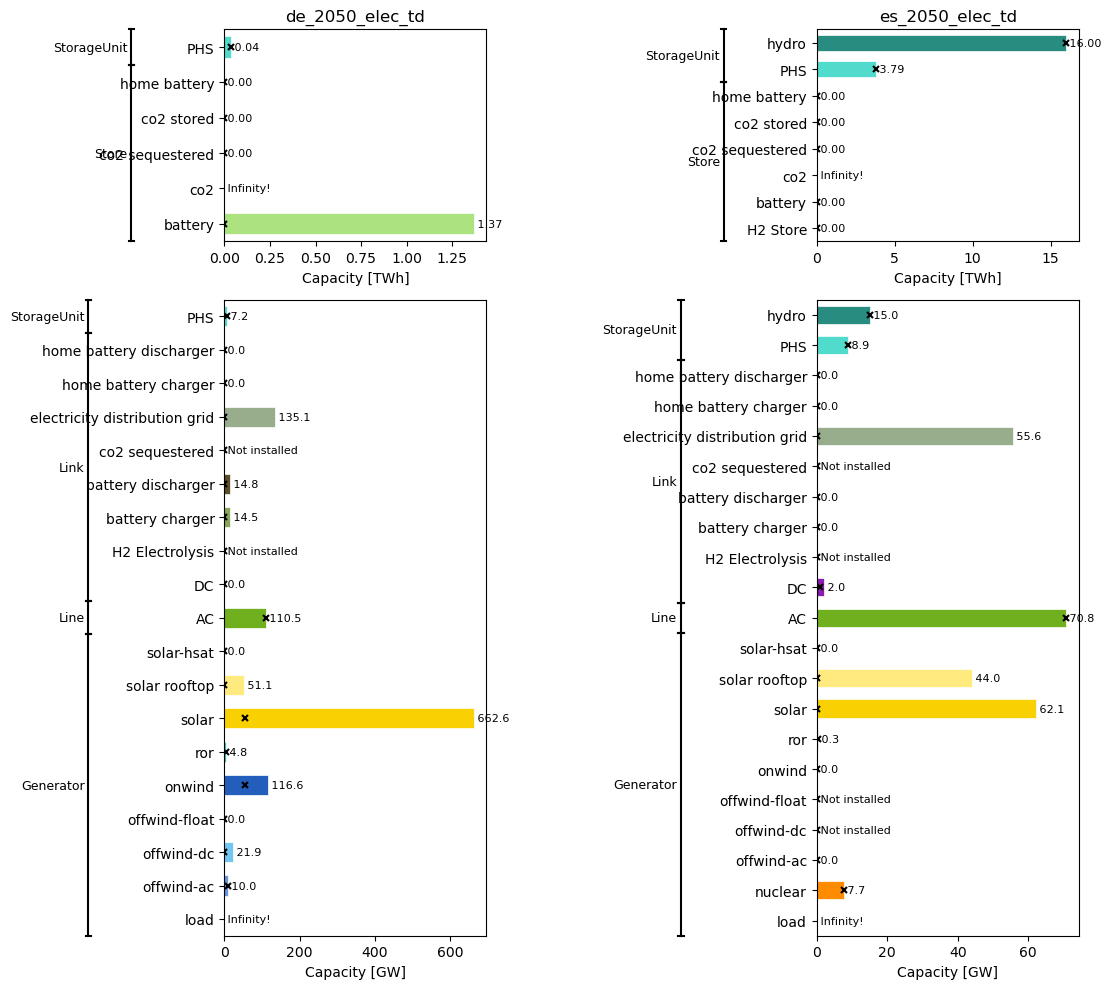

In [ ]:
runs = ["de_2050_elec_td", "es_2050_elec_td"]

fig, ax = plt.subplots(2, len(runs), figsize=(6 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier").drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier").drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

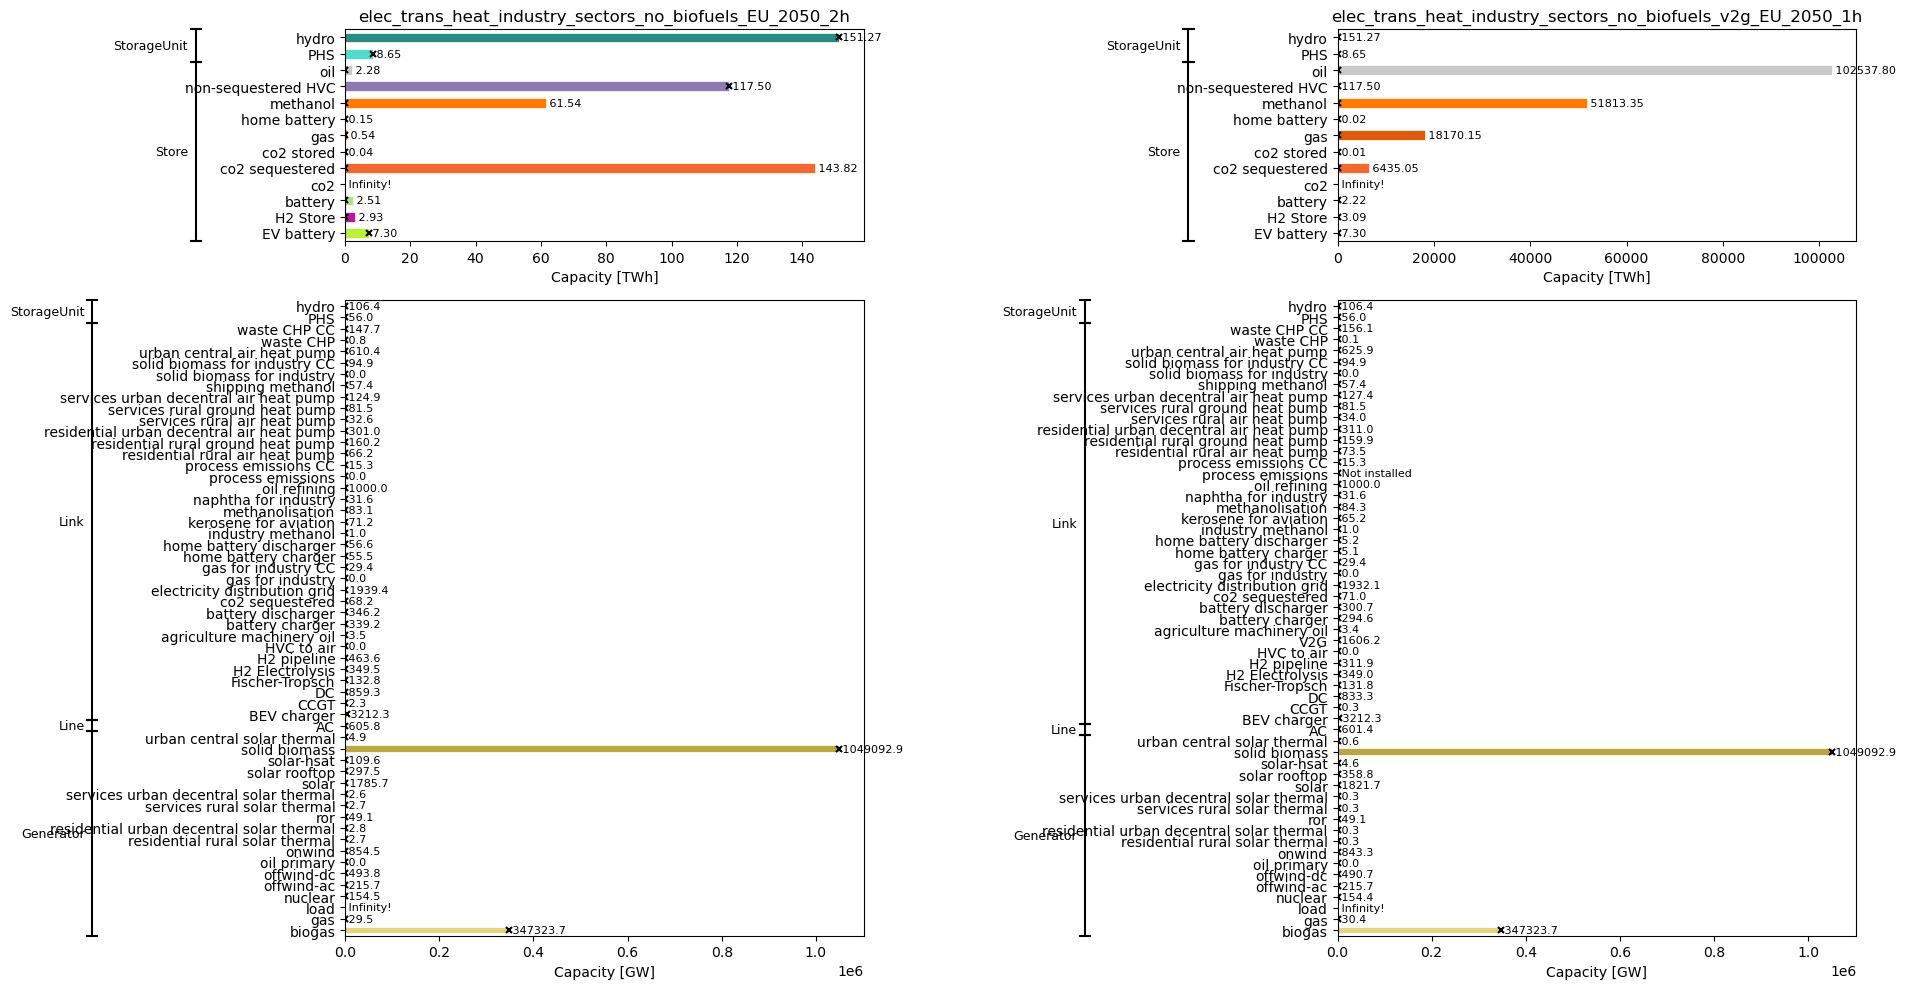

In [10]:
runs = [sample_new_2h_2050, sample_1h_2050]

fig, ax = plt.subplots(2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier").drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier").drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

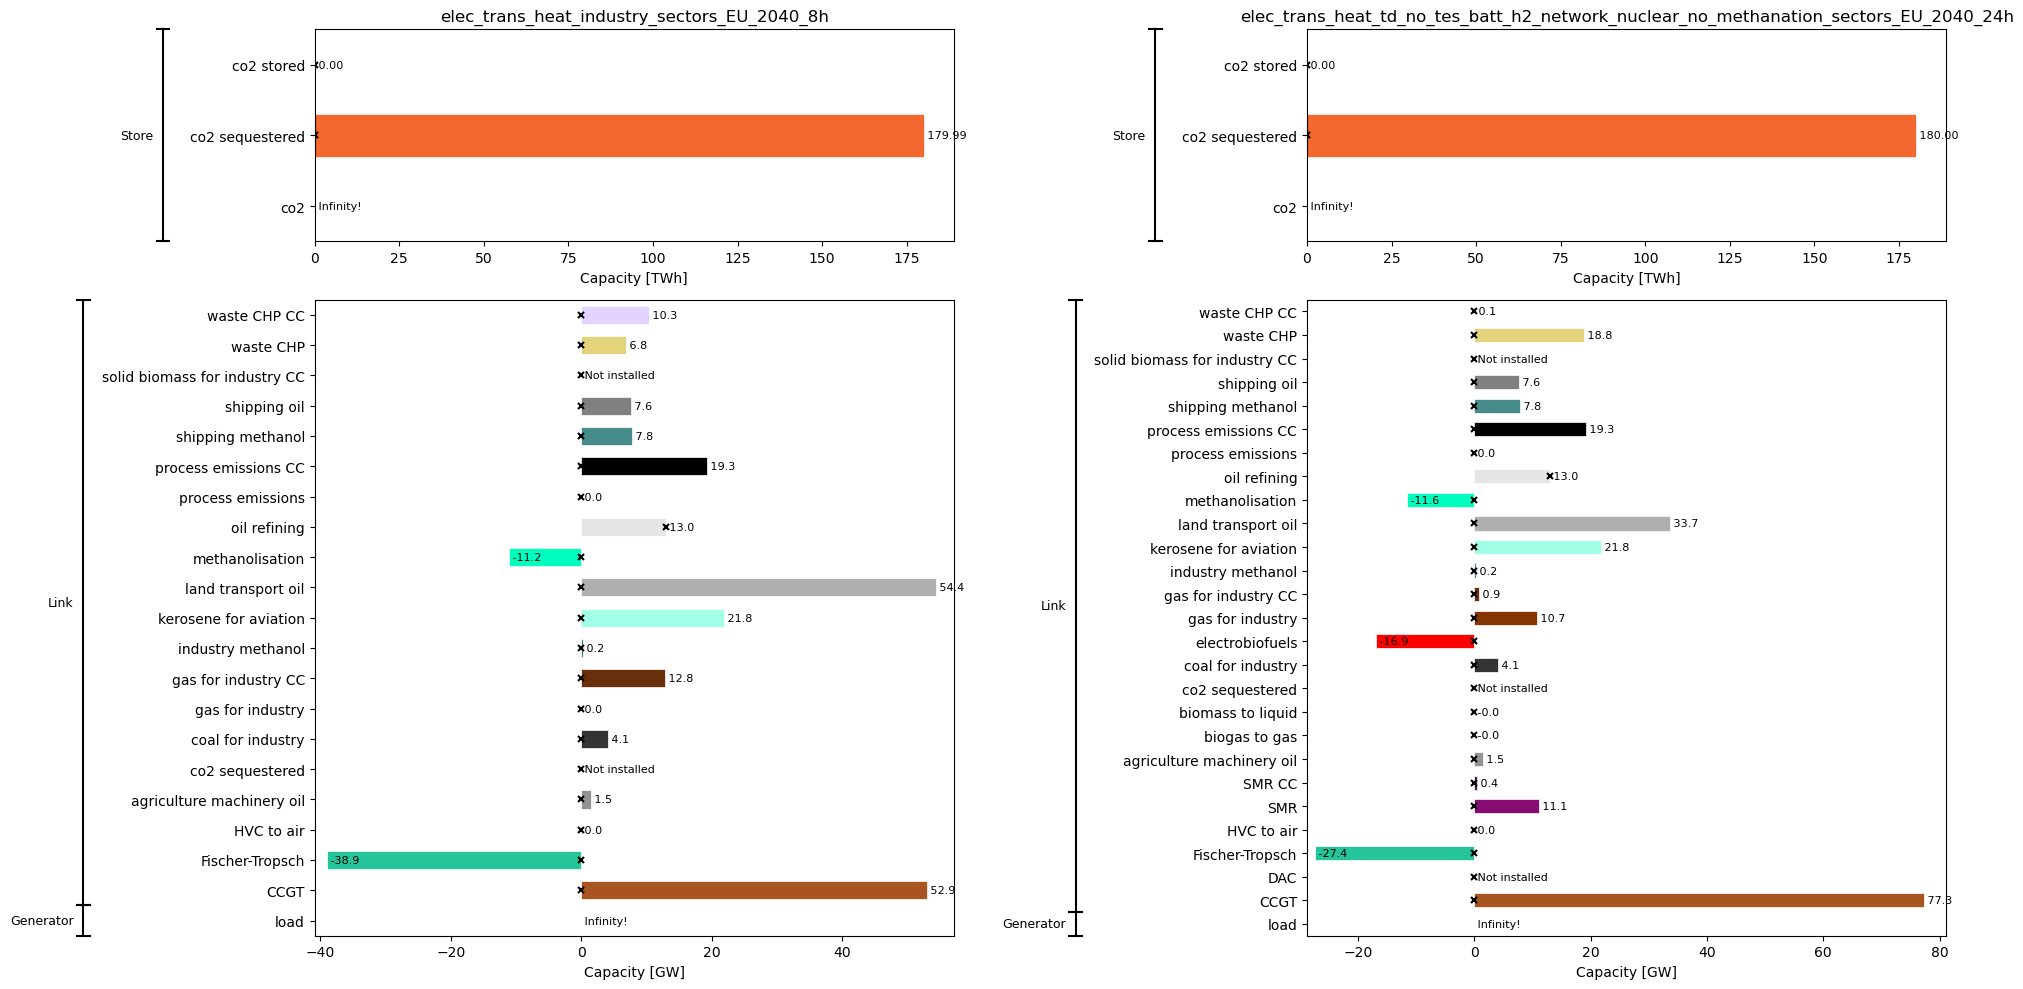

In [57]:
runs = [sample_8h, sample2]
co2_carriers = ['co2', 'co2 sequestered', 'co2 stored']

fig, ax = plt.subplots(2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=co2_carriers)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=co2_carriers)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=co2_carriers).drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=co2_carriers).drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

battery storage: 2.4 GWh

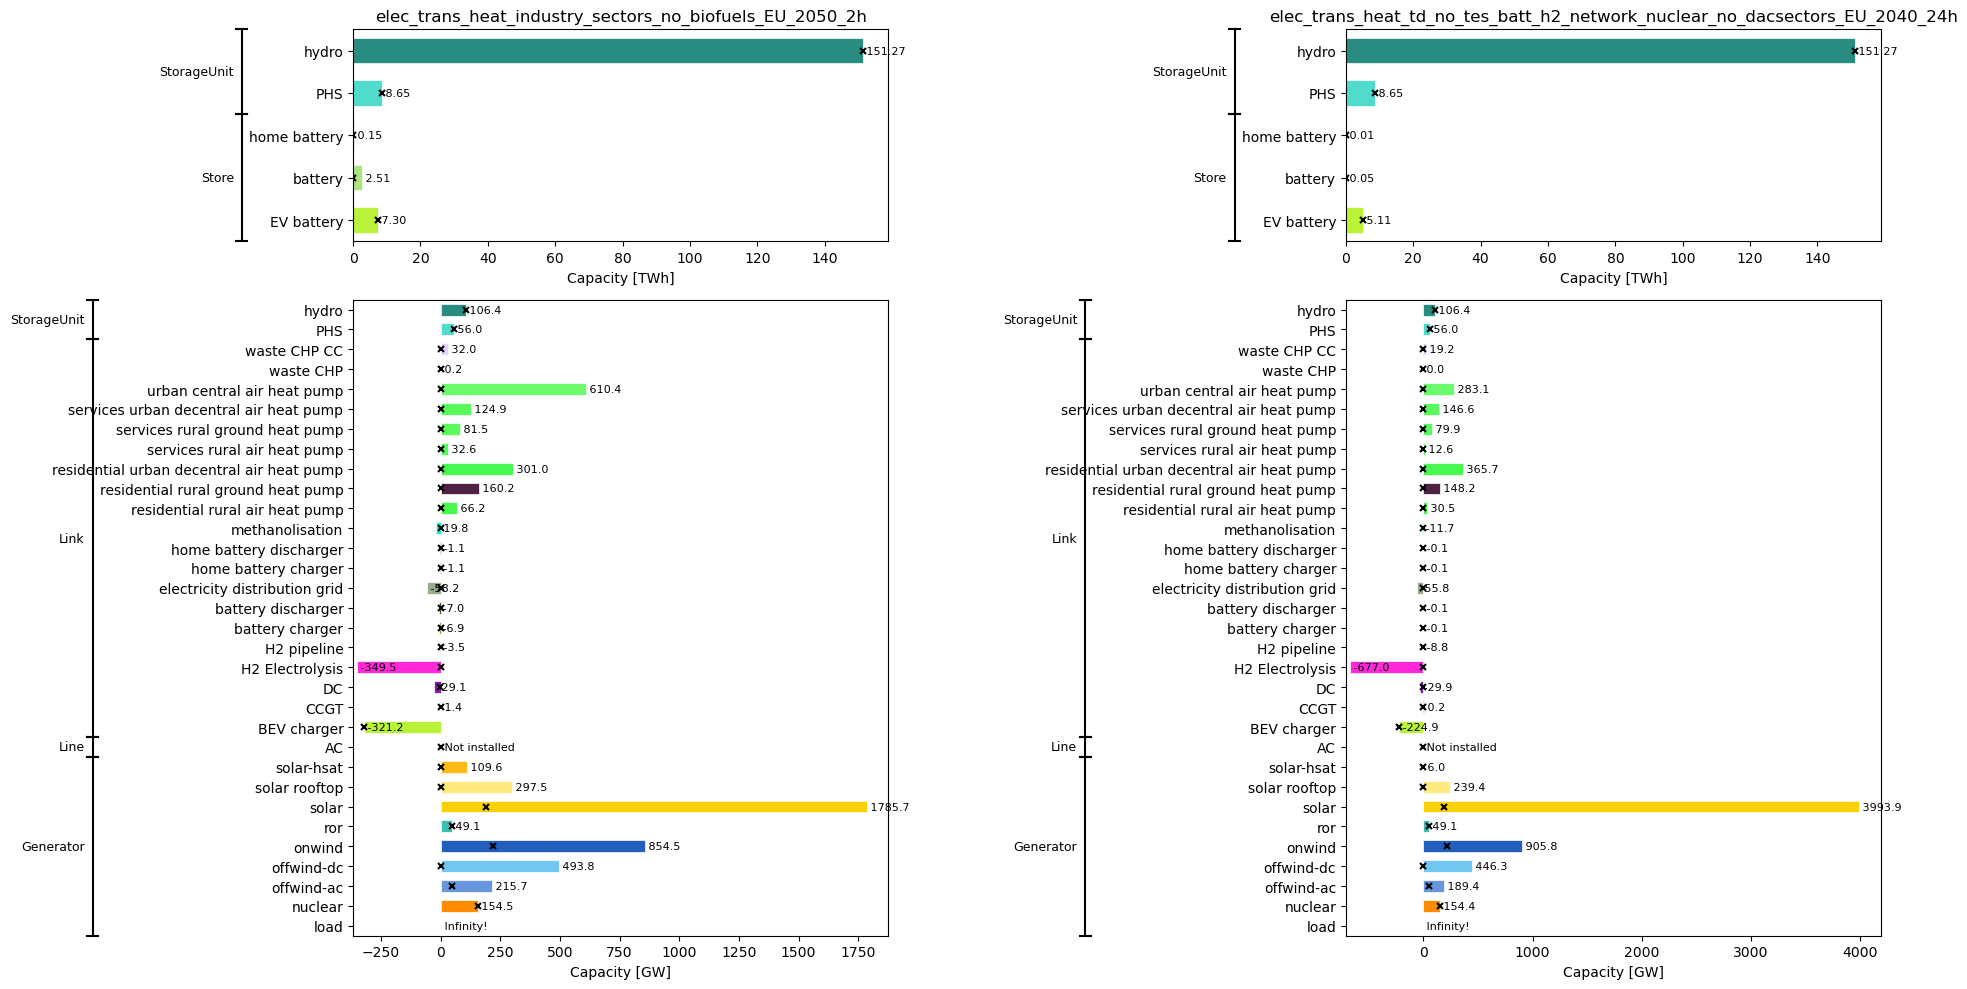

In [11]:
runs = [sample_new_2h_2050, "elec_trans_heat_td_no_tes_batt_h2_network_nuclear_no_dacsectors_EU_2040_24h"]
elec_carriers = ['AC', 'DC', 'Battery Storage', 'home battery', 'low voltage', 'EV battery', 'Battery Storage', 'battery']

fig, ax = plt.subplots(2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

## Yearly energy generation

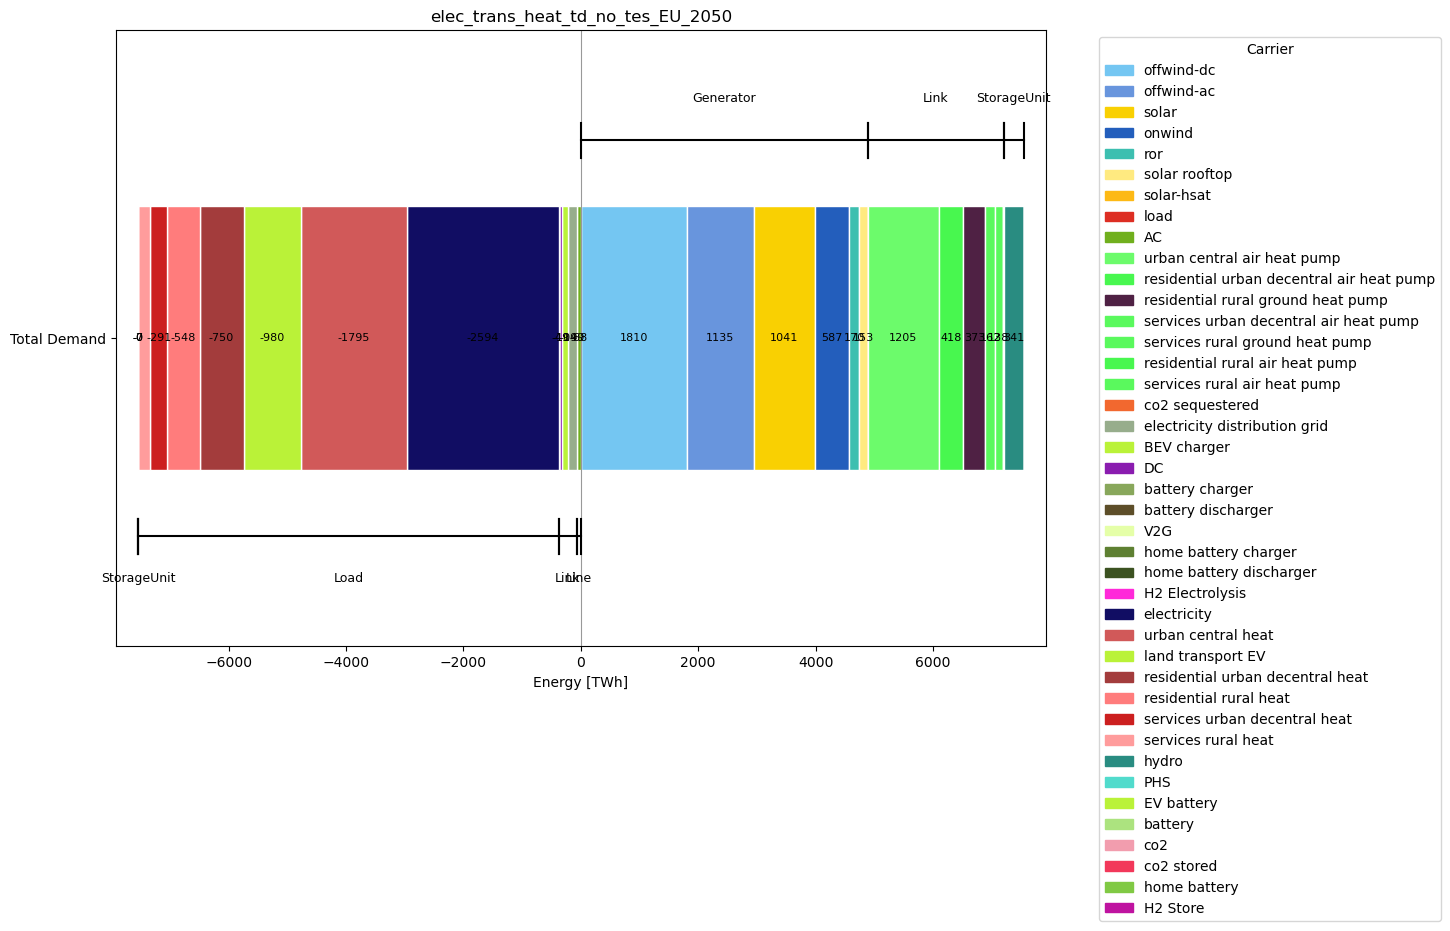

In [ ]:
runs = ["elec_trans_heat_td_no_tes_EU_2050"]
fig, ax = plt.subplots(1, len(runs), figsize=(12 * len(runs), 8))

eb = {}

for i, run in enumerate(runs):
    eb = stats[run].energy_balance(drop_zero=False, nice_names=False, round=3, groupby="carrier")
    # mask = eb.index.get_level_values(1).str.contains("heat")
    # eb_filt = eb[mask]

    stacked_barh_signed(
        eb / 1e6,  # TWh
        ax,
        tech_colors=tech_colors,
        y_label="Total Demand",
    )

    ax.set_title(f"{run}")
    ax.set_xlabel("Energy [TWh]")

plt.show()


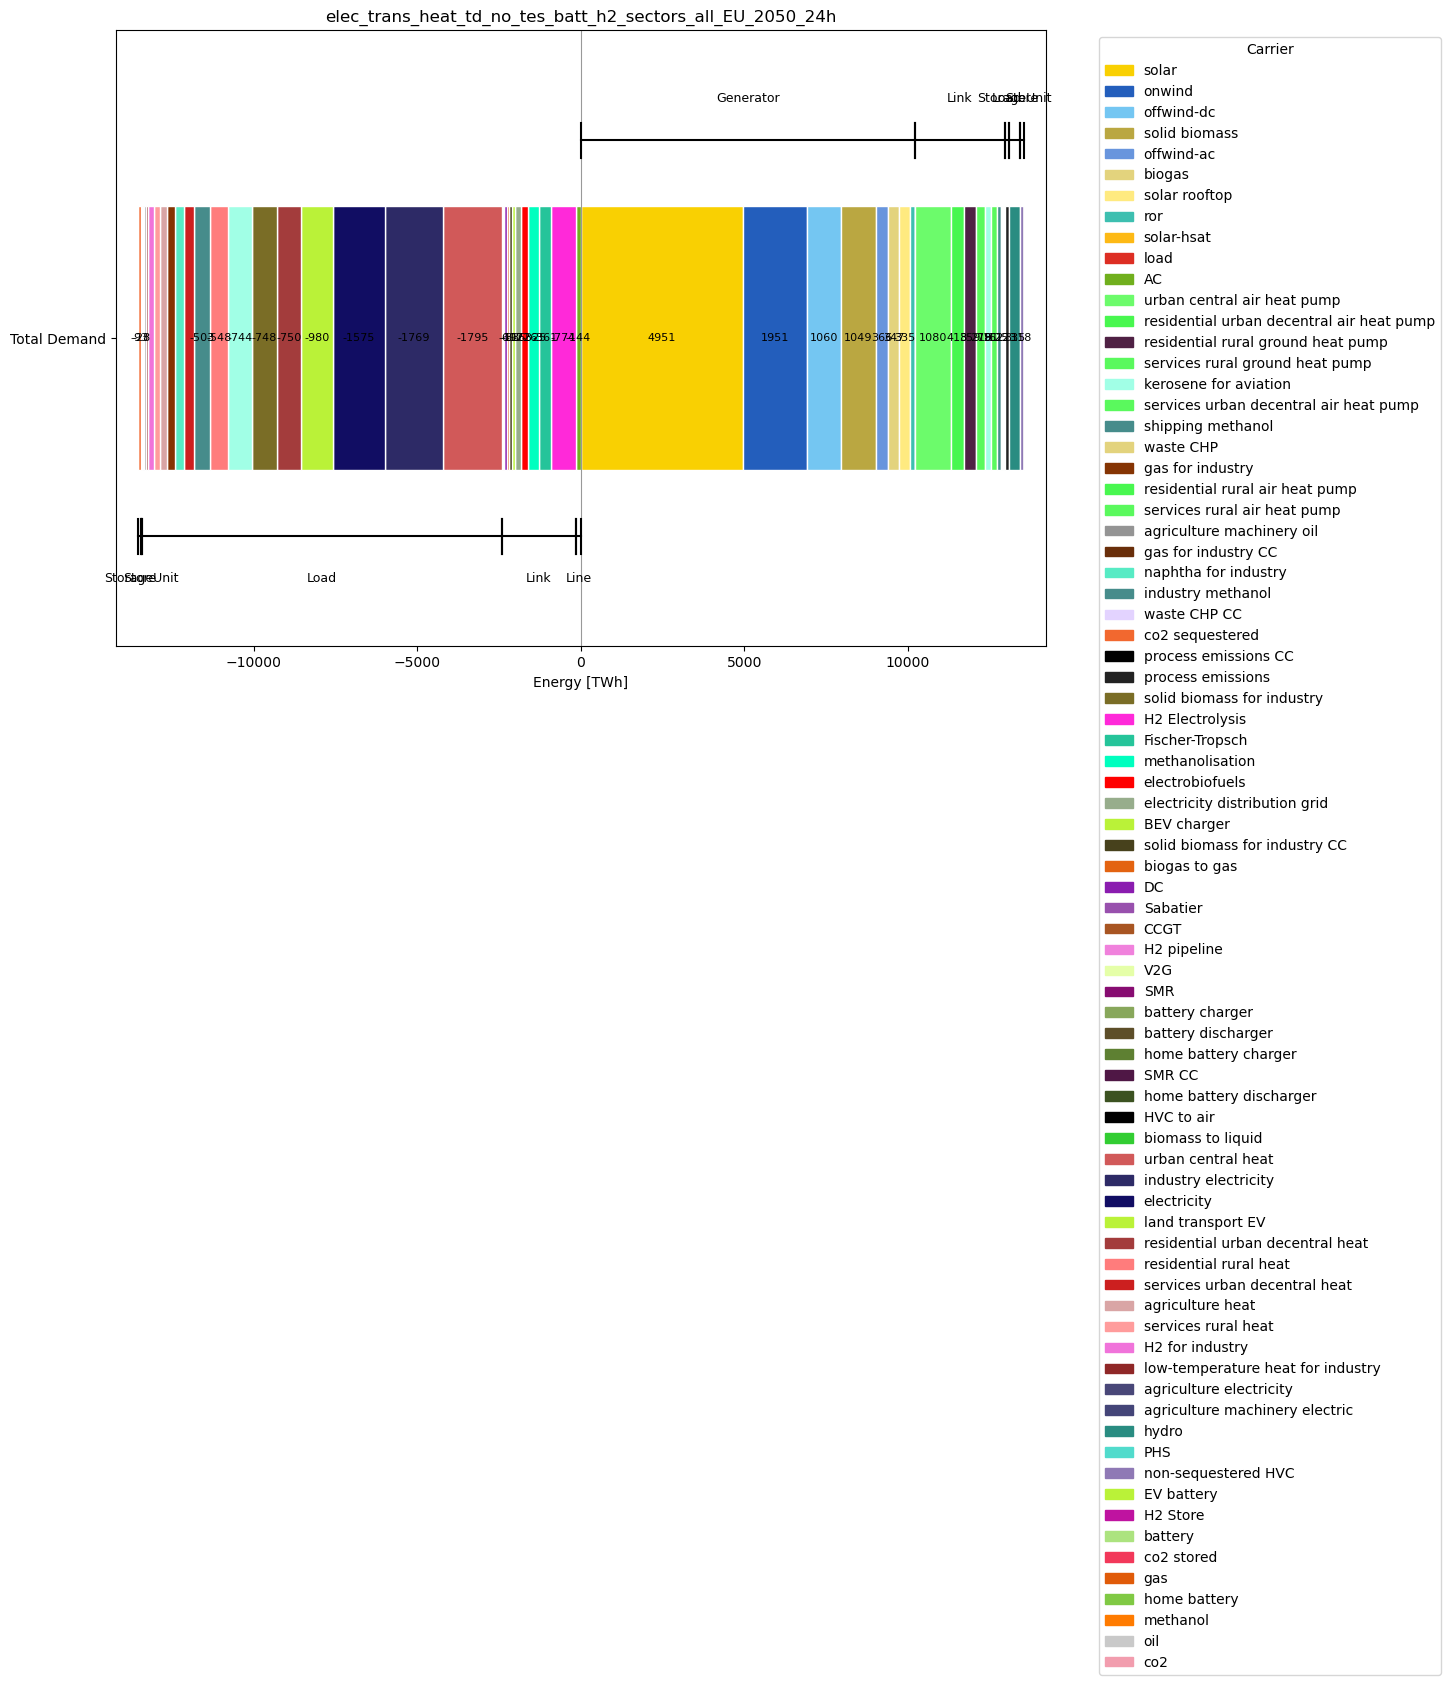

In [ ]:
runs = ["elec_trans_heat_td_no_tes_batt_h2_sectors_all_EU_2050_24h"]
fig, ax = plt.subplots(1, len(runs), figsize=(12 * len(runs), 8))

eb = {}

for i, run in enumerate(runs):
    eb = stats[run].energy_balance(drop_zero=False, nice_names=False, round=3, groupby="carrier")
    # mask = eb.index.get_level_values(1).str.contains("heat")
    # eb_filt = eb[mask]

    stacked_barh_signed(
        eb / 1e6,  # TWh
        ax,
        tech_colors=tech_colors,
        y_label="Total Demand",
    )

    ax.set_title(f"{run}")
    ax.set_xlabel("Energy [TWh]")

plt.show()


## Mineral intensities

Compare overall mineral usage

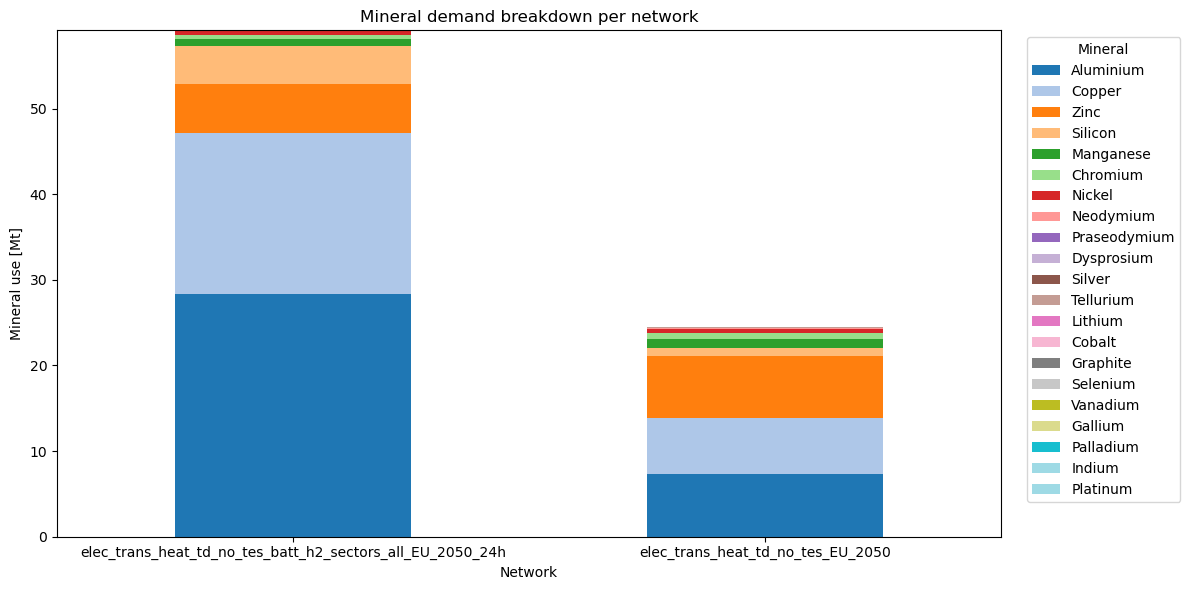

(              elec_trans_heat_td_no_tes_batt_h2_sectors_all_EU_2050_24h  \
 Aluminium                                          2.837834e+01           
 Copper                                             1.879615e+01           
 Zinc                                               5.746403e+00           
 Silicon                                            4.407310e+00           
 Manganese                                          8.223272e-01           
 Chromium                                           5.316603e-01           
 Nickel                                             3.861580e-01           
 Neodymium                                          7.511909e-02           
 Praseodymium                                       1.245959e-02           
 Dysprosium                                         7.865972e-03           
 Silver                                             4.964023e-03           
 Tellurium                                          1.224768e-03           
 Lithium    

In [225]:
compare_networks(["elec_trans_heat_td_no_tes_batt_h2_sectors_all_EU_2050_24h", "elec_trans_heat_td_no_tes_EU_2050"], n, minerals, tech_scenarios, mineral_intensities)

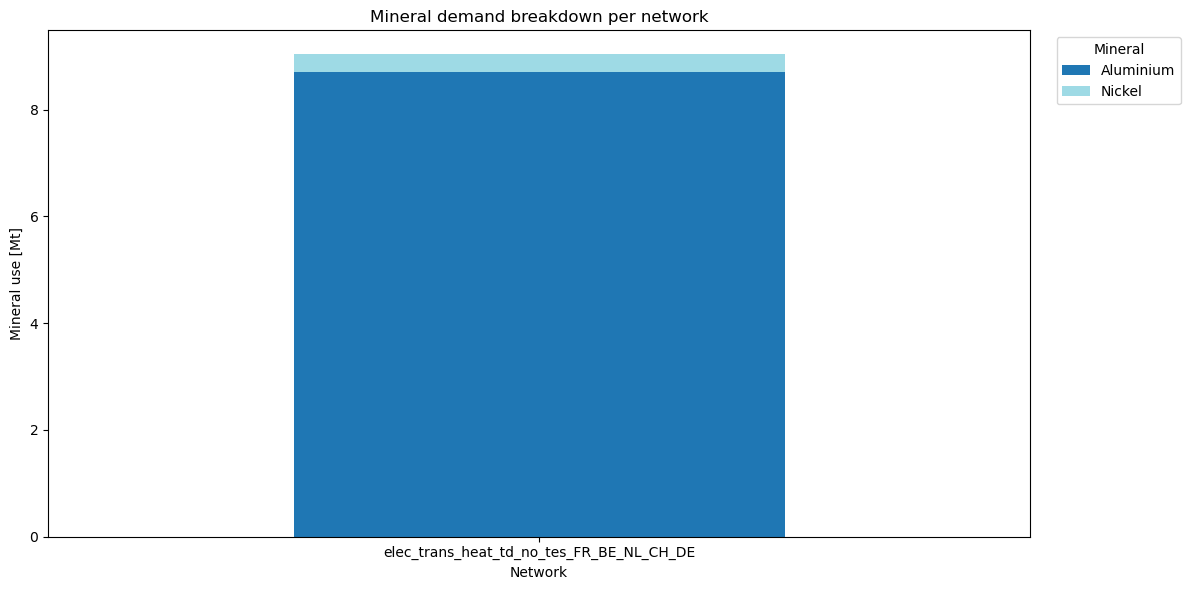

(           elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE
 Aluminium                                  8.714465
 Nickel                                     0.322852,
 {'elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE':     component             carrier  carrier capacity    PyPSA technology  \
  0   Generator  Offshore Wind (AC)      9.010338e+03  Offshore Wind (AC)   
  1   Generator  Offshore Wind (AC)      9.010338e+03  Offshore Wind (AC)   
  2   Generator  Offshore Wind (AC)      9.010338e+03  Offshore Wind (AC)   
  3   Generator  Offshore Wind (AC)      9.010338e+03  Offshore Wind (AC)   
  4   Generator  Offshore Wind (DC)      3.271383e+05  Offshore Wind (DC)   
  5   Generator  Offshore Wind (DC)      3.271383e+05  Offshore Wind (DC)   
  6   Generator  Offshore Wind (DC)      3.271383e+05  Offshore Wind (DC)   
  7   Generator  Offshore Wind (DC)      3.271383e+05  Offshore Wind (DC)   
  8   Generator        Onshore Wind      5.479940e+05        Onshore Wind   
  9   Generator        Ons

In [ ]:
compare_networks(["elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE"], n, ["Nickel", "Aluminium"], tech_scenarios, mineral_intensities)

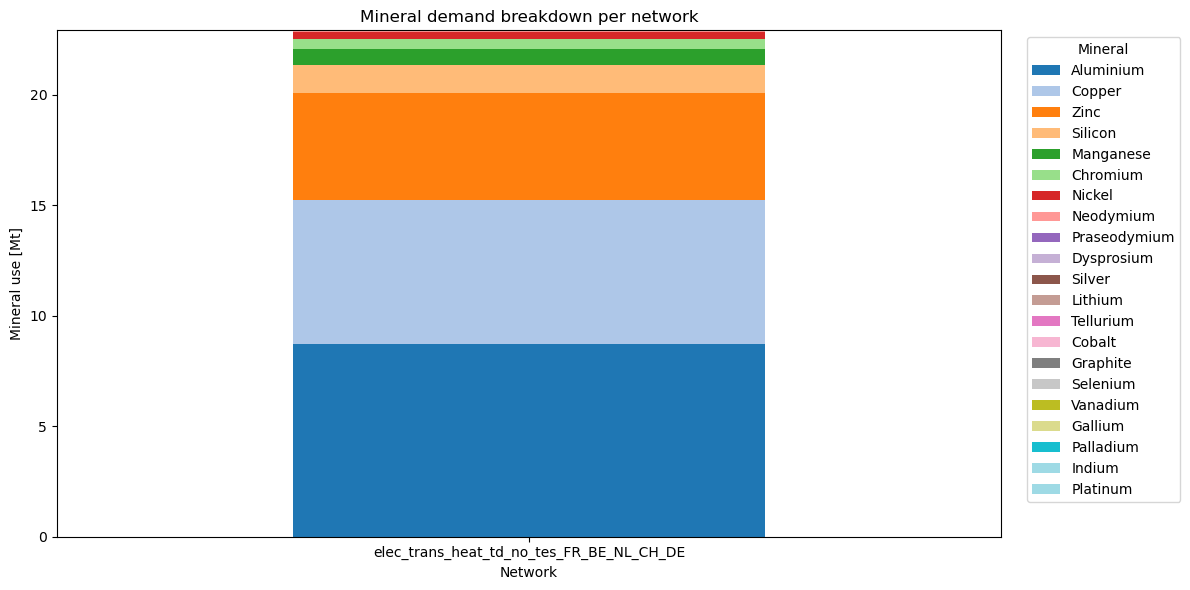

(              elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE
 Aluminium                                 8.714465e+00
 Copper                                    6.507232e+00
 Zinc                                      4.863864e+00
 Silicon                                   1.255571e+00
 Manganese                                 6.969385e-01
 Chromium                                  4.529347e-01
 Nickel                                    3.228516e-01
 Neodymium                                 6.829297e-02
 Praseodymium                              1.146151e-02
 Dysprosium                                7.078133e-03
 Silver                                    1.414722e-03
 Lithium                                   5.888797e-04
 Tellurium                                 3.476473e-04
 Cobalt                                    3.238262e-04
 Graphite                                  2.196382e-05
 Selenium                                  2.759256e-06
 Vanadium                                  1.104

In [ ]:
compare_networks(["elec_trans_heat_td_no_tes_FR_BE_NL_CH_DE"], n, minerals, tech_scenarios, mineral_intensities)

In [127]:
pd.set_option('display.max_rows', 500)

n[sample_new_2h_2050].statistics.expanded_capacity()

component    carrier                                  
Generator    Offshore Wind (AC)                           1.679217e+05
             Offshore Wind (DC)                           4.938259e+05
             Onshore Wind                                 6.370688e+05
             Run of River                                 0.000000e+00
             Solar                                        1.597403e+06
             biogas                                       0.000000e+00
             gas                                          2.945555e+04
             load                                         0.000000e+00
             nuclear                                      1.069380e+02
             oil primary                                  4.610000e-01
             residential rural solar thermal              2.674264e+03
             residential urban decentral solar thermal    2.781223e+03
             services rural solar thermal                 2.702725e+03
             services 

### Sankey diagrams

In [19]:
network_key = sample_new_2h_2050
df_merged, totals_Mt = compute_mineral_usage(network_key, n, minerals, "Scenario EV SiB", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    minerals,
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

In [20]:
battery_minerals = ["Lithium", "Cobalt", "Graphite"]
network_key = sample_new_2h_2050
df_merged, totals_Mt = compute_mineral_usage(network_key, n, battery_minerals, "Scenario EV SiB", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    battery_minerals,
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

In [22]:
network_key = "elec_trans_heat_td_no_tes_batt_h2_network_nuclear_sectors_EU_2040_24h"
df_merged, totals_Mt = compute_mineral_usage(network_key, n, rare_earths, "Market share current", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    rare_earths,
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

To do: 
- Try criticality scores with different countries to validate scores. 


- Note: for supply comparison, we are comparing *yearly* supply (from IEA) to total cumulative demand from energy system until 2050

### Cumulative mineral use

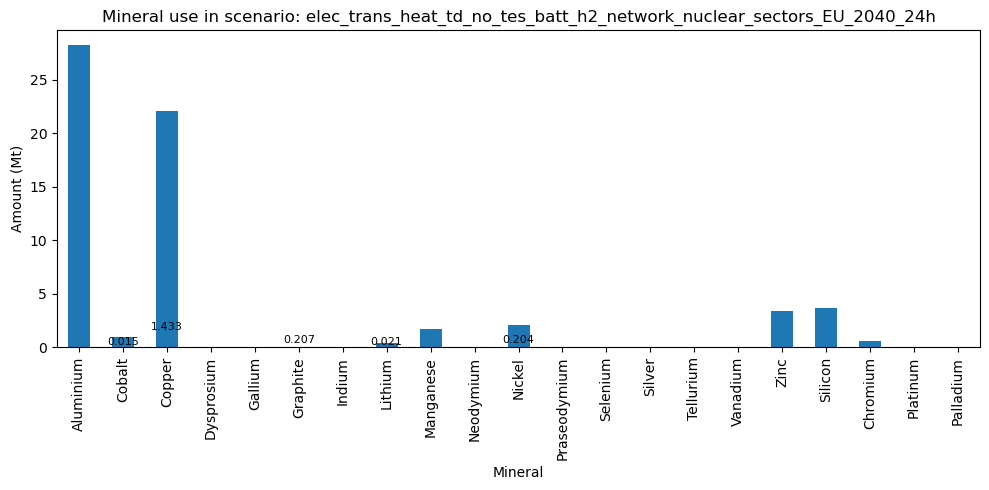

In [61]:
network_key = "elec_trans_heat_td_no_tes_batt_h2_network_nuclear_sectors_EU_2040_24h"
df_merged, totals_Mt = compute_mineral_usage(network_key, n, minerals, "Market share current", mineral_intensities, tech_scenarios)


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = totals_Mt.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("Mineral")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")


# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

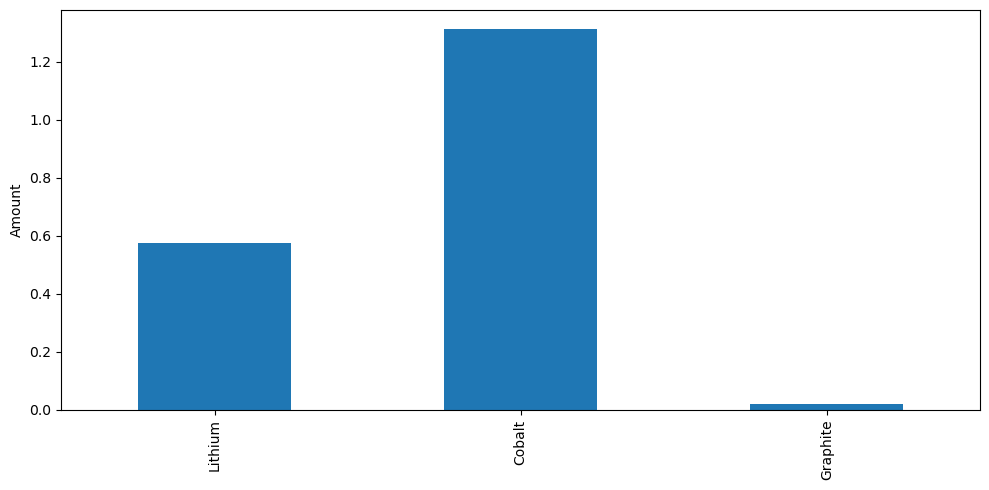

In [ ]:
network_key = sample_new_2h_2050
df_merged, totals_Mt = compute_mineral_usage(network_key, n, ["Lithium", "Cobalt", "Graphite"], mineral_intensities, tech_scenarios)


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = totals_Mt.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant


plt.tight_layout()
plt.show()

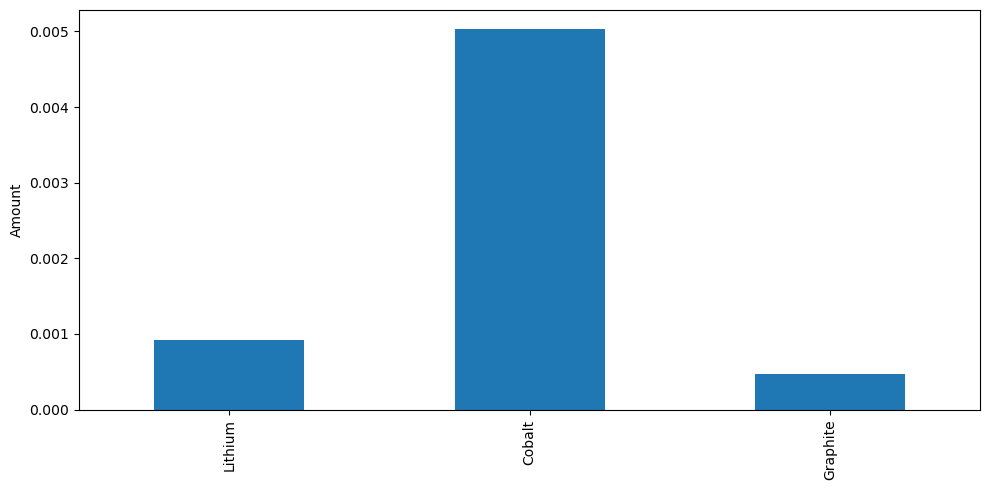

In [ ]:
network_key = sample_new_2h_2050
df_merged, totals_Mt = compute_mineral_usage(network_key, n, ["Lithium", "Cobalt", "Graphite"], mineral_intensities, tech_scenarios)


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = totals_Mt.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant


plt.tight_layout()
plt.show()

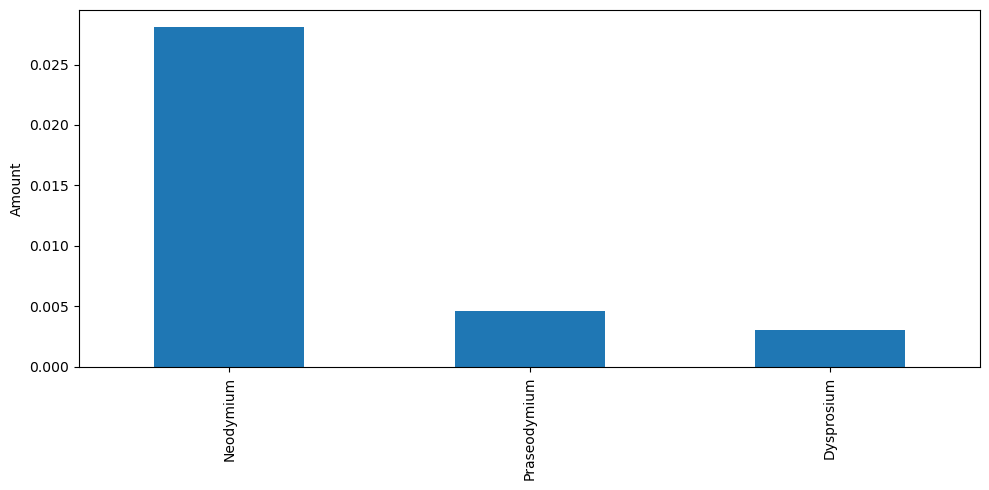

In [ ]:
network_key = sample
df_merged, totals_Mt = compute_mineral_usage(network_key, n, rare_earths, mineral_intensities, tech_scenarios)


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = totals_Mt.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
plt.tight_layout()
plt.show()

In [126]:
mineral_alloc_tidy

,Method,metal,supply,Supply (Mt)
0,Total global,Copper,15836.000,15.836000
1,GDP share,Copper,3373.068,3.373068
2,Per capita share,Copper,1076.848,1.076848
3,Per capita share corrected for energy use,Copper,728.456,0.728456
4,Total global,Cobalt,214.000,0.214000
5,GDP share,Cobalt,45.582,0.045582
6,Per capita share,Cobalt,14.552,0.014552
7,Per capita share corrected for energy use,Cobalt,9.844,0.009844
8,Total global,Lithium,418.000,0.418000
9,GDP share,Lithium,89.034,0.089034


### Yearly mineral use

In [23]:
def mineral_allocation_comp(network_key, n, minerals, mineral_intensities, tech_scenarios, mineral_alloc):
    network_key = sample
    time_diff = 14
    df_merged, totals_Mt = compute_mineral_usage(network_key, n, minerals, mineral_intensities, tech_scenarios)
    totals_Mt_yearly = totals_Mt/time_diff


    # s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
    ax = totals_Mt_yearly.plot.bar(figsize=(10,5), color="C0")
    ax.set_ylabel("Amount (Mt)")        # change units/label as needed
    ax.set_xlabel("Mineral")              # remove x-label if redundant
    ax.set_title(f"Mineral use in scenario: {network_key}")

    supply_pce = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share corrected for energy use'].set_index('metal')['Supply (Mt)']
    supply_gdp = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'GDP share'].set_index('metal')['Supply (Mt)']

    # read current tick positions & labels from the existing axis `ax`
    positions = ax.get_xticks()
    labels = [t.get_text() for t in ax.get_xticklabels()]

    xs = []
    ys = []

    xs1 = []
    ys1 = []
    for x_pos, lab in zip(positions, labels):
        if lab in supply_pce.index:
            xs.append(x_pos)
            ys.append(supply_pce.loc[lab])
        if lab in supply_gdp.index:
            xs1.append(x_pos)
            ys1.append(supply_gdp.loc[lab])

    # plot points on top of the bars
    ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Supply (Mt)')
    ax.scatter(xs1, ys1, color='red', marker='D', s=80, edgecolor='k', zorder=10, label='Supply (Mt)')

    # optional: annotate numeric values
    for x, y in zip(xs, ys):
        ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

    for x, y in zip(xs1, ys1):
        ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

Red: GDP share
Green: per capita share corrected for energy use

In [48]:
supply = mineral_avail[mineral_avail['Estimate method'] == 'Supply'].set_index('Mineral')['Value (Mt)']
supply_gdp = mineral_avail[mineral_avail['Estimate method'] == 'Supply'].set_index('Mineral')['Value (Mt)'] * mineral_alloc_factors["GDP share"]
supply_pc = mineral_avail[mineral_avail['Estimate method'] == 'Supply'].set_index('Mineral')['Value (Mt)'] * mineral_alloc_factors["Per capita share"]
supply_pce = mineral_avail[mineral_avail['Estimate method'] == 'Supply'].set_index('Mineral')['Value (Mt)'] * mineral_alloc_factors["Per capita share corrected for energy use"]

prod = mineral_avail[mineral_avail['Estimate method'] == 'Production'].set_index('Mineral')['Value (Mt)']
prod_gdp = mineral_avail[mineral_avail['Estimate method'] == 'Production'].set_index('Mineral')['Value (Mt)'] * mineral_alloc_factors["GDP share"]
prod_pc = mineral_avail[mineral_avail['Estimate method'] == 'Production'].set_index('Mineral')['Value (Mt)'] * mineral_alloc_factors["Per capita share"]
prod_pce = mineral_avail[mineral_avail['Estimate method'] == 'Production'].set_index('Mineral')['Value (Mt)'] * mineral_alloc_factors["Per capita share corrected for energy use"]



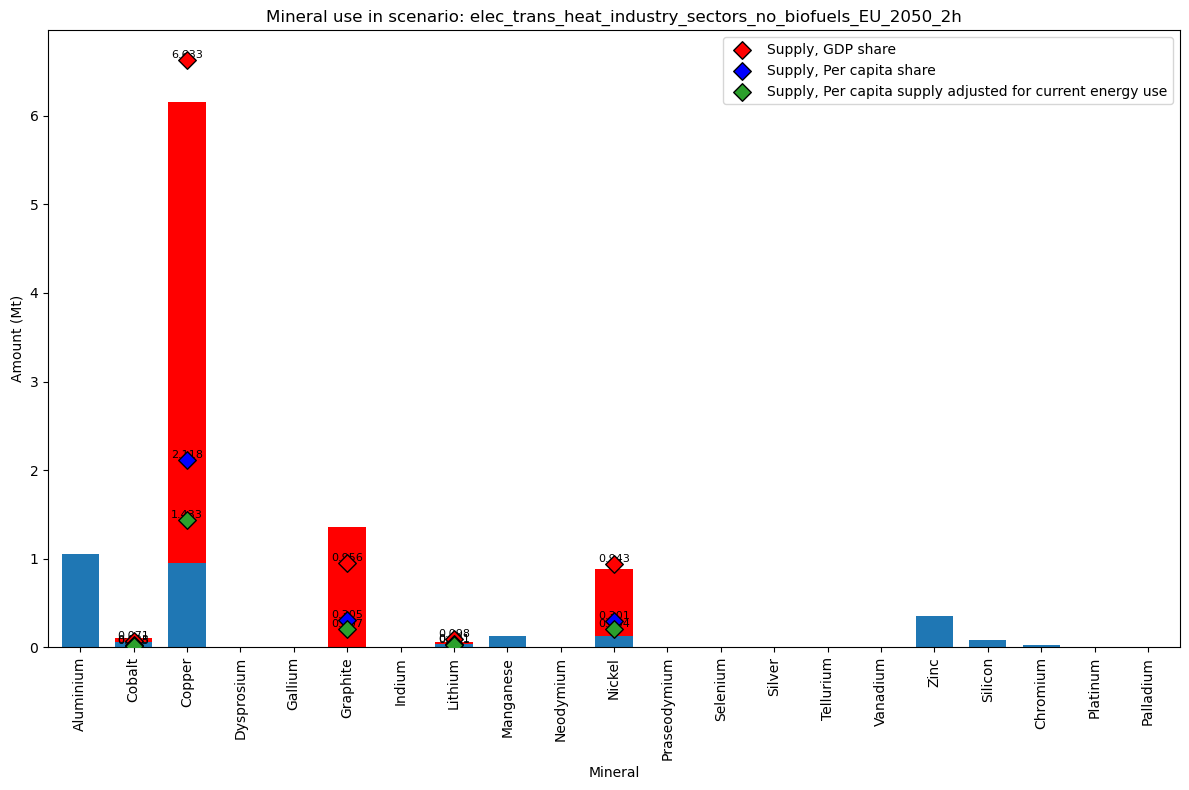

In [117]:
network_key = sample_new_2h_2050
time_diff = 24
df_merged, totals_Mt = compute_mineral_usage(network_key, n, minerals, "Market share current", mineral_intensities, tech_scenarios)
totals_Mt_yearly = totals_Mt/time_diff


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = totals_Mt_yearly.plot.bar(figsize=(12,8), color="C0", width = 0.7)
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("Mineral")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")


# read current tick positions & labels from the existing axis `ax`
positions = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

xs = []
ys = []

xs1 = []
ys1 = []

xs2 = []
ys2 = []

xs3 = []
ys3 = []

xs4 = []
ys4 = []

xs5 = []
ys5 = []

xs6 = []
ys6 = []
bottom = []

for x_pos, lab in zip(positions, labels):
    if lab in supply.index:
        xs.append(x_pos)
        ys.append(supply_pce.loc[lab])

        xs1.append(x_pos)
        ys1.append(supply_gdp.loc[lab])

        xs2.append(x_pos)
        ys2.append(supply_pc.loc[lab])
    if lab in prod.index: 
        xs3.append(x_pos)
        ys3.append(prod_pce.loc[lab])

        xs4.append(x_pos)
        ys4.append(prod_gdp.loc[lab])

        xs5.append(x_pos)
        ys5.append(prod_pc.loc[lab])
    if lab in non_energy_demand.index: 
        xs6.append(x_pos)
        ys6.append(non_energy_demand.loc[lab]["Value entso-e (Mt)"])
        bottom.append(totals_Mt_yearly.loc[lab])

ax.bar(xs6, ys6, bottom = bottom, color="red", width=0.7)

# plot supply points on top of the bars
ax.scatter(xs1, ys1, color='red', marker='D', s=80, edgecolor='k', zorder=10, label='Supply, GDP share')
ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Supply, Per capita share')
ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Supply, Per capita supply adjusted for current energy use')

# plot production points on top of the bars
# ax.scatter(xs3, ys3, color='red', marker='o', s=80, edgecolor='k', zorder=10, label='Current production, GDP share')
# ax.scatter(xs4, ys4, color='blue', marker='o', s=80, edgecolor='k', zorder=10, label='Current production, Per capita share')
# ax.scatter(xs5, ys5, color='C2', marker='o', s=80, edgecolor='k', zorder=10, label='Current production, Per capita supply adjusted for current energy use')



# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs1, ys1):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs2, ys2):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)


plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [111]:
ys6

[0.03195, 0.046433999999999996]

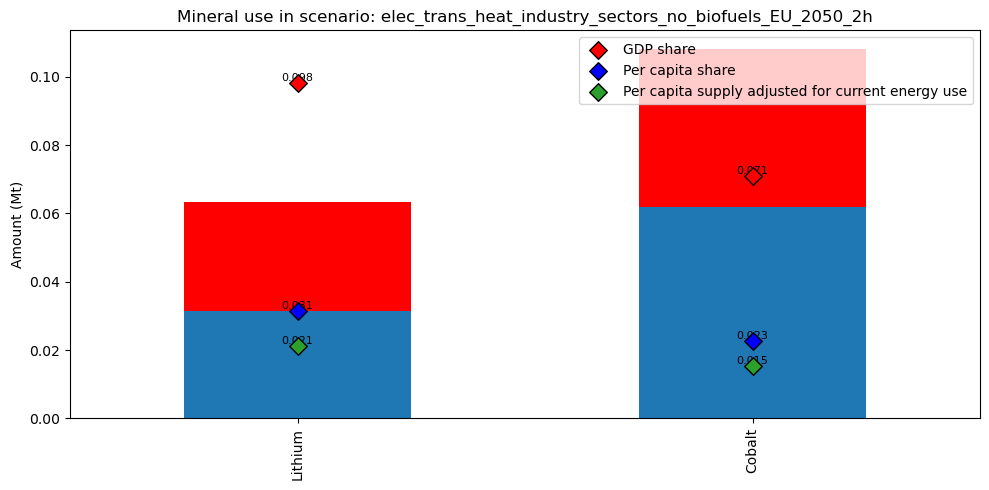

In [116]:
network_key = sample_new_2h_2050
time_diff = 24
df_merged, totals_Mt = compute_mineral_usage(network_key, n, ["Lithium", "Cobalt"], "Market share current", mineral_intensities, tech_scenarios)
totals_Mt_yearly = totals_Mt/time_diff


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = totals_Mt_yearly.plot.bar(figsize=(10,5), color="C0", width = 0.5)
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")

supply_pce = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share corrected for energy use'].set_index('metal')['Supply (Mt)']
supply_gdp = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'GDP share'].set_index('metal')['Supply (Mt)']
supply_pc = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share'].set_index('metal')['Supply (Mt)']

# read current tick positions & labels from the existing axis `ax`
positions = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

xs = []
ys = []

xs1 = []
ys1 = []

xs2 = []
ys2 = []

xs6 = []
ys6 = []
bottom = []

for x_pos, lab in zip(positions, labels):
    if lab in supply_pce.index:
        xs.append(x_pos)
        ys.append(supply_pce.loc[lab])
    if lab in supply_gdp.index:
        xs1.append(x_pos)
        ys1.append(supply_gdp.loc[lab])
    if lab in supply_pc.index:
        xs2.append(x_pos)
        ys2.append(supply_pc.loc[lab])
    if lab in non_energy_demand.index:
        xs6.append(x_pos)
        ys6.append(non_energy_demand.loc[lab]["Value entso-e (Mt)"])
        bottom.append(totals_Mt_yearly.loc[lab])

ax.bar(xs6, ys6, bottom = bottom, color="red", width=0.5)

# plot points on top of the bars
ax.scatter(xs1, ys1, color='red', marker='D', s=80, edgecolor='k', zorder=10, label='GDP share')
ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita share')
ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita supply adjusted for current energy use')


# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs1, ys1):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs2, ys2):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)


plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

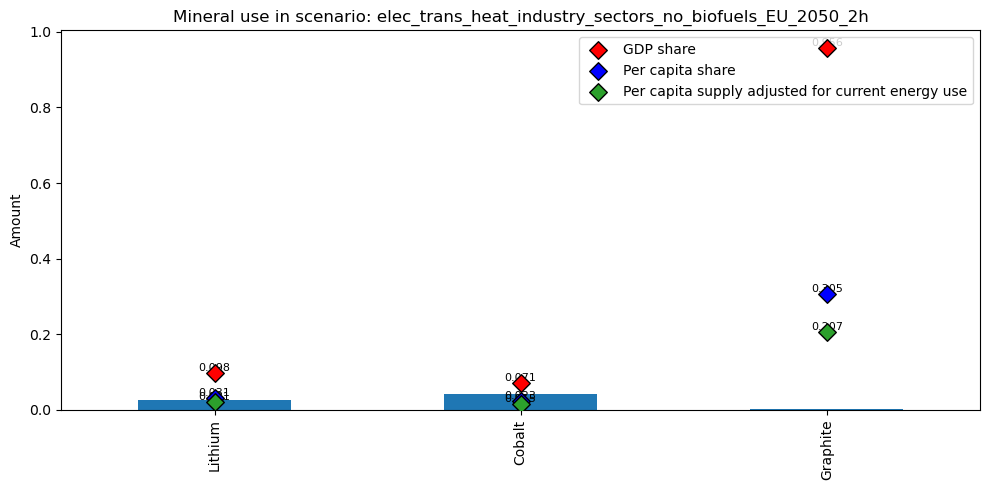

In [ ]:
network_key = sample_new_2h_2050
time_diff = 24
df_merged, totals_Mt = compute_mineral_usage(network_key, n, ["Lithium", "Cobalt", "Graphite"], "Scenario EV NMC 811", mineral_intensities, tech_scenarios)
totals_Mt_yearly = totals_Mt/time_diff


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = totals_Mt_yearly.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")

supply_pce = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share corrected for energy use'].set_index('metal')['Supply (Mt)']
supply_gdp = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'GDP share'].set_index('metal')['Supply (Mt)']
supply_pc = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share'].set_index('metal')['Supply (Mt)']

# read current tick positions & labels from the existing axis `ax`
positions = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

xs = []
ys = []

xs1 = []
ys1 = []

xs2 = []
ys2 = []

for x_pos, lab in zip(positions, labels):
    if lab in supply_pce.index:
        xs.append(x_pos)
        ys.append(supply_pce.loc[lab])
    if lab in supply_gdp.index:
        xs1.append(x_pos)
        ys1.append(supply_gdp.loc[lab])
    if lab in supply_pc.index:
        xs2.append(x_pos)
        ys2.append(supply_pc.loc[lab])

# plot points on top of the bars
ax.scatter(xs1, ys1, color='red', marker='D', s=80, edgecolor='k', zorder=10, label='GDP share')
ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita share')
ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita supply adjusted for current energy use')


# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs1, ys1):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs2, ys2):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)


plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

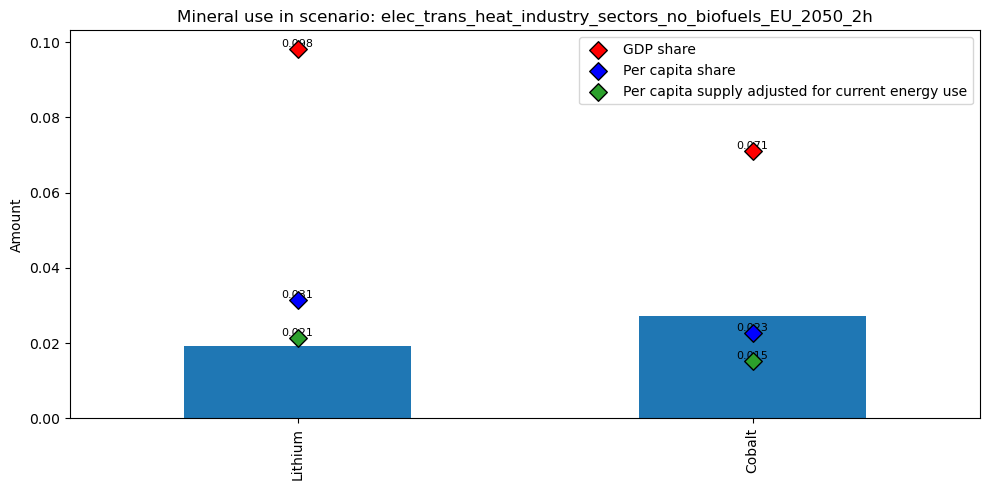

In [ ]:
network_key = sample_new_2h_2050
time_diff = 24
df_merged, totals_Mt = compute_mineral_usage(network_key, n, ["Lithium", "Cobalt"], "Scenario EV SiB", mineral_intensities, tech_scenarios)
totals_Mt_yearly = totals_Mt/time_diff


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = totals_Mt_yearly.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")

supply_pce = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share corrected for energy use'].set_index('metal')['Supply (Mt)']
supply_gdp = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'GDP share'].set_index('metal')['Supply (Mt)']
supply_pc = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share'].set_index('metal')['Supply (Mt)']

# read current tick positions & labels from the existing axis `ax`
positions = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

xs = []
ys = []

xs1 = []
ys1 = []

xs2 = []
ys2 = []

for x_pos, lab in zip(positions, labels):
    if lab in supply_pce.index:
        xs.append(x_pos)
        ys.append(supply_pce.loc[lab])
    if lab in supply_gdp.index:
        xs1.append(x_pos)
        ys1.append(supply_gdp.loc[lab])
    if lab in supply_pc.index:
        xs2.append(x_pos)
        ys2.append(supply_pc.loc[lab])

# plot points on top of the bars
ax.scatter(xs1, ys1, color='red', marker='D', s=80, edgecolor='k', zorder=10, label='GDP share')
ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita share')
ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita supply adjusted for current energy use')


# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs1, ys1):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs2, ys2):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)


plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

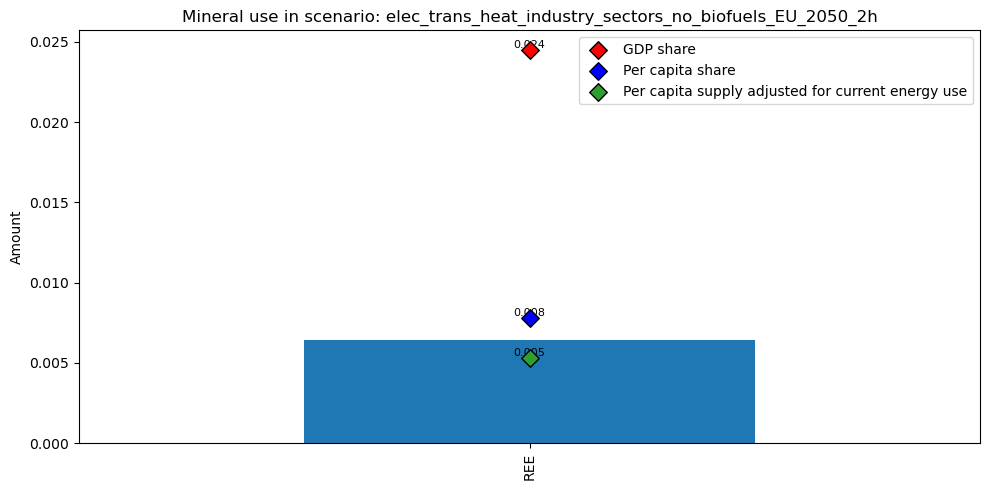

In [ ]:
network_key = sample_new_2h_2050
time_diff = 24
df_merged, totals_Mt = compute_mineral_usage(network_key, n, rare_earths, "Market share current", mineral_intensities, tech_scenarios)
total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
total_REEs_yearly = total_REEs/time_diff


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = total_REEs_yearly.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")

supply_pce = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share corrected for energy use'].set_index('metal')['Supply (Mt)']
supply_gdp = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'GDP share'].set_index('metal')['Supply (Mt)']
supply_pc = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share'].set_index('metal')['Supply (Mt)']

# read current tick positions & labels from the existing axis `ax`
positions = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

xs = []
ys = []

xs1 = []
ys1 = []

xs2 = []
ys2 = []

for x_pos, lab in zip(positions, labels):
    if lab in supply_pce.index:
        xs.append(x_pos)
        ys.append(supply_pce.loc[lab])
    if lab in supply_gdp.index:
        xs1.append(x_pos)
        ys1.append(supply_gdp.loc[lab])
    if lab in supply_pc.index:
        xs2.append(x_pos)
        ys2.append(supply_pc.loc[lab])

# plot points on top of the bars
ax.scatter(xs1, ys1, color='red', marker='D', s=80, edgecolor='k', zorder=10, label='GDP share')
ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita share')
ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita supply adjusted for current energy use')


# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs1, ys1):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs2, ys2):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)


plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [254]:
network_key = sample_new_2h_2050
time_diff = 24
df_merged, totals_Mt = compute_mineral_usage(network_key, n, rare_earths, mineral_intensities, tech_scenarios)

total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
total_REEs_yearly = total_REEs/time_diff


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = total_REEs_yearly.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("Mineral")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")

supply_pce = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share corrected for energy use'].set_index('metal')['Supply (Mt)']
supply_gdp = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'GDP share'].set_index('metal')['Supply (Mt)']
supply_pc = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share'].set_index('metal')['Supply (Mt)']

# read current tick positions & labels from the existing axis `ax`
positions = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

xs = []
ys = []

xs1 = []
ys1 = []

xs2 = []
ys2 = []

for x_pos, lab in zip(positions, labels):
    if lab in supply_pce.index:
        xs.append(x_pos)
        ys.append(supply_pce.loc[lab])
    if lab in supply_gdp.index:
        xs1.append(x_pos)
        ys1.append(supply_gdp.loc[lab])
    if lab in supply_pc.index:
        xs2.append(x_pos)
        ys2.append(supply_pc.loc[lab])

# plot points on top of the bars
ax.scatter(xs1, ys1, color='red', marker='D', s=80, edgecolor='k', zorder=10, label='GDP share')
ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita share')
ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita supply adjusted for current energy use')


# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs1, ys1):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs2, ys2):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

TypeError: Can only merge Series or DataFrame objects, a <class 'NoneType'> was passed

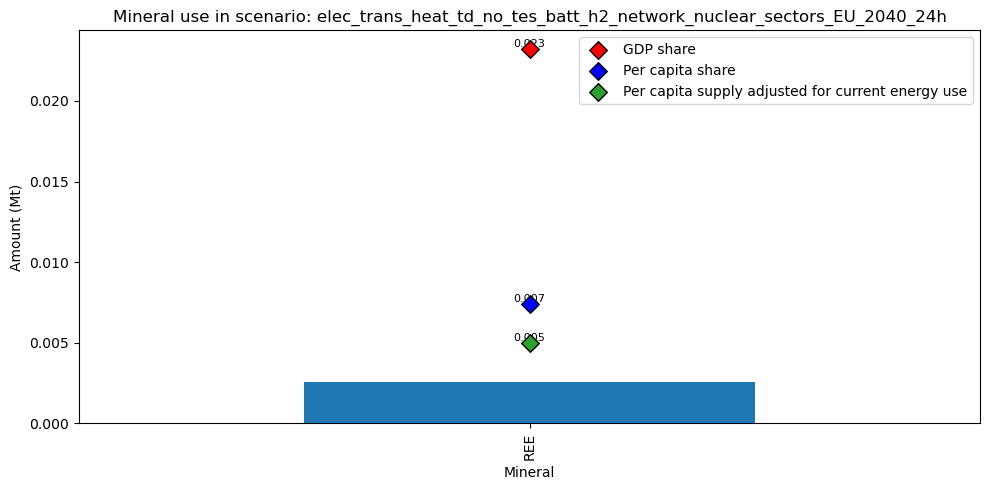

In [42]:
network_key = sample1
time_diff = 14
df_merged, totals_Mt = compute_mineral_usage(network_key, n, rare_earths, mineral_intensities, tech_scenarios)

total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
total_REEs_yearly = total_REEs/time_diff


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = total_REEs_yearly.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("Mineral")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")

supply_pce = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share corrected for energy use'].set_index('metal')['Supply (Mt)']
supply_gdp = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'GDP share'].set_index('metal')['Supply (Mt)']
supply_pc = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share'].set_index('metal')['Supply (Mt)']

# read current tick positions & labels from the existing axis `ax`
positions = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

xs = []
ys = []

xs1 = []
ys1 = []

xs2 = []
ys2 = []

for x_pos, lab in zip(positions, labels):
    if lab in supply_pce.index:
        xs.append(x_pos)
        ys.append(supply_pce.loc[lab])
    if lab in supply_gdp.index:
        xs1.append(x_pos)
        ys1.append(supply_gdp.loc[lab])
    if lab in supply_pc.index:
        xs2.append(x_pos)
        ys2.append(supply_pc.loc[lab])

# plot points on top of the bars
ax.scatter(xs1, ys1, color='red', marker='D', s=80, edgecolor='k', zorder=10, label='GDP share')
ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita share')
ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita supply adjusted for current energy use')


# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs1, ys1):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs2, ys2):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

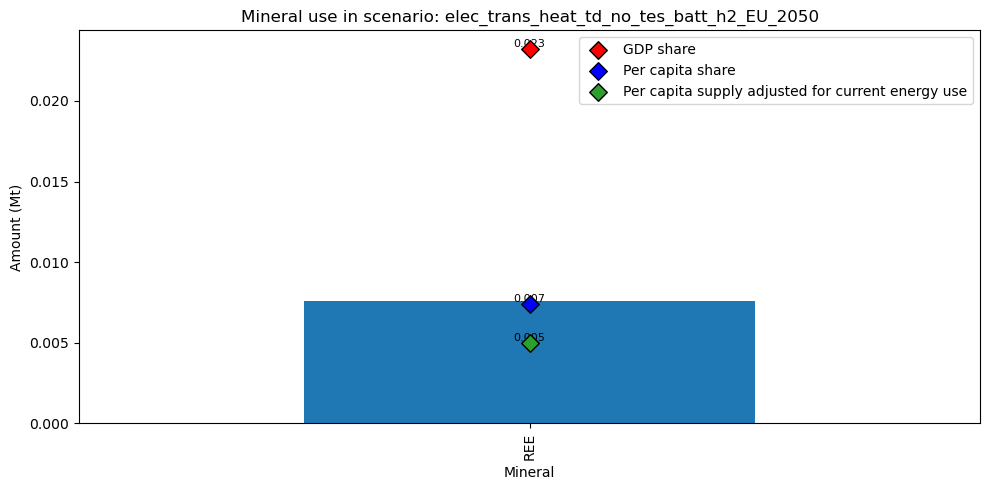

In [37]:
network_key = sample_no_sectors
time_diff = 24
df_merged, totals_Mt = compute_mineral_usage(network_key, n, rare_earths, mineral_intensities, tech_scenarios)

total_REEs = pd.Series(data = {'REE': totals_Mt.sum()}, index=['REE'])
total_REEs_yearly = total_REEs/time_diff


# s = expanded_capacities[minerals].sum()   # example Series, index = mineral names
ax = total_REEs_yearly.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount (Mt)")        # change units/label as needed
ax.set_xlabel("Mineral")              # remove x-label if redundant
ax.set_title(f"Mineral use in scenario: {network_key}")

supply_pce = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share corrected for energy use'].set_index('metal')['Supply (Mt)']
supply_gdp = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'GDP share'].set_index('metal')['Supply (Mt)']
supply_pc = mineral_alloc_tidy[mineral_alloc_tidy['Method'] == 'Per capita share'].set_index('metal')['Supply (Mt)']

# read current tick positions & labels from the existing axis `ax`
positions = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]

xs = []
ys = []

xs1 = []
ys1 = []

xs2 = []
ys2 = []

for x_pos, lab in zip(positions, labels):
    if lab in supply_pce.index:
        xs.append(x_pos)
        ys.append(supply_pce.loc[lab])
    if lab in supply_gdp.index:
        xs1.append(x_pos)
        ys1.append(supply_gdp.loc[lab])
    if lab in supply_pc.index:
        xs2.append(x_pos)
        ys2.append(supply_pc.loc[lab])

# plot points on top of the bars
ax.scatter(xs1, ys1, color='red', marker='D', s=80, edgecolor='k', zorder=10, label='GDP share')
ax.scatter(xs2, ys2, color='blue', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita share')
ax.scatter(xs, ys, color='C2', marker='D', s=80, edgecolor='k', zorder=10, label='Per capita supply adjusted for current energy use')


# optional: annotate numeric values
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs1, ys1):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

for x, y in zip(xs2, ys2):
    ax.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Scenario mineral comparison

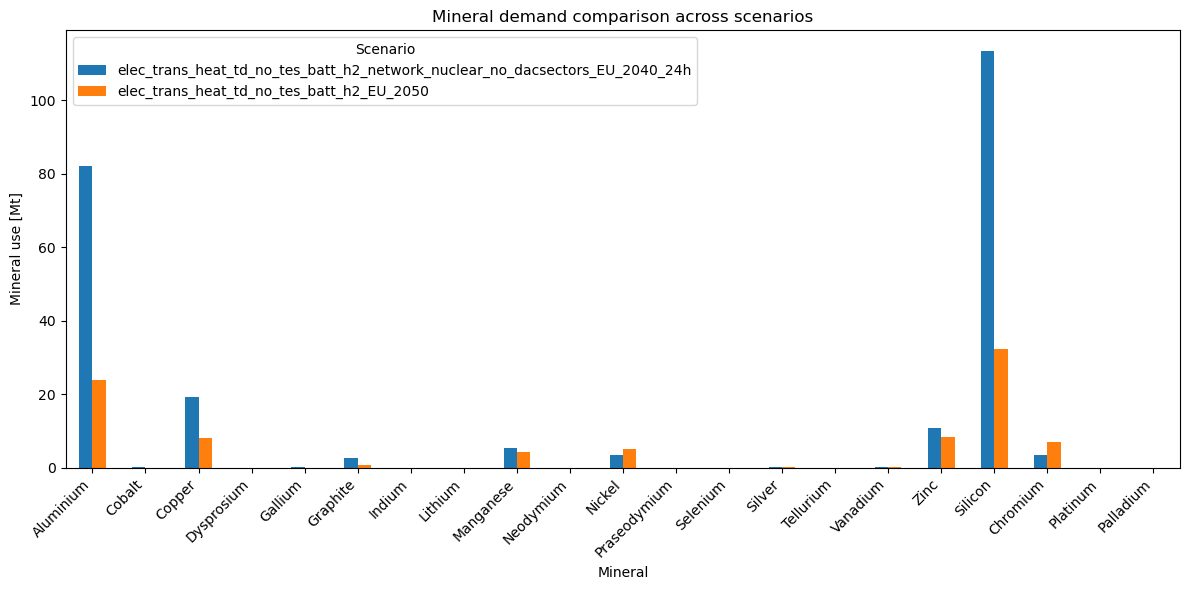

In [163]:
scenarios_to_compare = [sample3, sample_no_sectors]
mineral_data = {}

for scenario_name in scenarios_to_compare:
    expanded_capacities = pd.DataFrame(n[scenario_name].statistics.expanded_capacity().reset_index()).rename(columns={0: 'capacity'})
    
    expanded_capacities["lci_technology"] = expanded_capacities["carrier"].map(techs_map["technology_map"])
    expanded_capacities = pd.merge(expanded_capacities, mineral_intensities, left_on='lci_technology', right_on='Activity', how='inner')
    
    expanded_capacities[minerals] = expanded_capacities[minerals].mul(expanded_capacities.capacity, axis=0)
    
    mineral_data[scenario_name] = expanded_capacities[minerals].sum() / (1000*1000*1000)  # Mt

# Create DataFrame with both scenarios (minerals as rows, scenarios as columns)
comparison_df = pd.DataFrame(mineral_data)

# Plot side-by-side bars
ax = comparison_df.plot.bar(figsize=(12, 6), color=["C0", "C1"])
ax.set_ylabel("Mineral use [Mt]")
ax.set_xlabel("Mineral")
ax.set_title("Mineral demand comparison across scenarios")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Scenario")
plt.tight_layout()
plt.show()

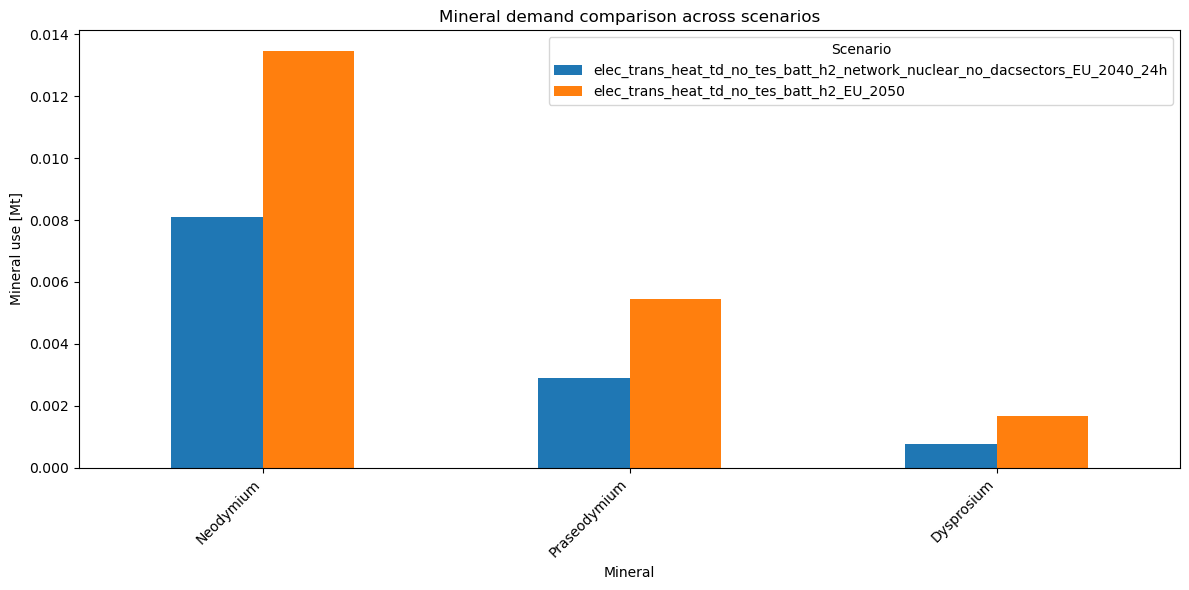

In [164]:
scenarios_to_compare = [sample3, sample_no_sectors]
mineral_data = {}

for scenario_name in scenarios_to_compare:
    expanded_capacities = pd.DataFrame(n[scenario_name].statistics.expanded_capacity().reset_index()).rename(columns={0: 'capacity'})
    
    expanded_capacities["lci_technology"] = expanded_capacities["carrier"].map(techs_map["technology_map"])
    expanded_capacities = pd.merge(expanded_capacities, mineral_intensities, left_on='lci_technology', right_on='Activity', how='inner')
    
    expanded_capacities[rare_earths] = expanded_capacities[rare_earths].mul(expanded_capacities.capacity, axis=0)
    
    mineral_data[scenario_name] = expanded_capacities[rare_earths].sum() / (1000*1000*1000)  # Mt

# Create DataFrame with both scenarios (minerals as rows, scenarios as columns)
comparison_df = pd.DataFrame(mineral_data)

# Plot side-by-side bars
ax = comparison_df.plot.bar(figsize=(12, 6), color=["C0", "C1"])
ax.set_ylabel("Mineral use [Mt]")
ax.set_xlabel("Mineral")
ax.set_title("Mineral demand comparison across scenarios")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Scenario")
plt.tight_layout()
plt.show()

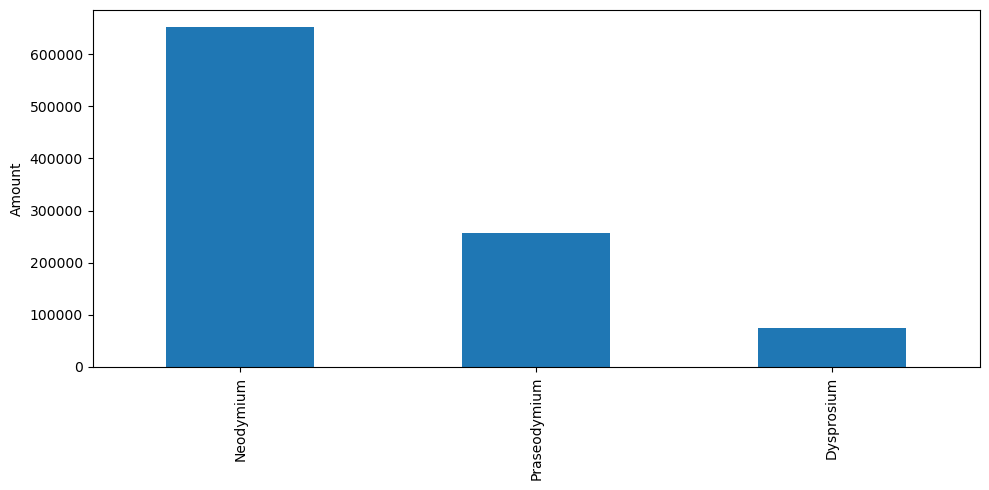

In [ ]:
s = expanded_capacities[rare_earths].sum()  # example Series, index = mineral names
ax = s.plot.bar(figsize=(10,5), color="C0")
ax.set_ylabel("Amount")        # change units/label as needed
ax.set_xlabel("")              # remove x-label if redundant
plt.tight_layout()
plt.show()

In [ ]:
expanded_capacities

,component,carrier,capacity,lci_technology,Activity,database,Friendly name,Activity long,Unit,Multiplier,...,Nickel,Palladium,Platinum,Praseodymium,Selenium,Silicon,Silver,Tellurium,Vanadium,Zinc
0,Generator,Offshore Wind (AC),0.00000,"wind power plant construction, 2MW, offshore, ...","wind power plant construction, 2MW, offshore, ...",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,"Wind, offshore, moving parts (Bonus 2 MW)","wind power plant construction, 2MW, offshore, ...",MW,2.000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-0.000000,0.000000,0.000000e+00
1,Generator,Onshore Wind,0.00000,"wind turbine construction, 4.5MW, onshore","wind turbine construction, 4.5MW, onshore",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,"Wind, onshore (Enercon E112)","wind turbine construction, 4.5MW, onshore (GLO)",MW,4.500,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-0.000000,0.000000,0.000000e+00
2,Generator,Solar,0.00000,"photovoltaic plant construction, 570kWp, multi...","photovoltaic plant construction, 570kWp, multi...",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,PV plant - multi-Si,"photovoltaic plant construction, 570kWp, multi...",MW,0.570,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
3,Generator,solar rooftop,73380.40552,"photovoltaic slanted-roof installation, 3kWp, ...","photovoltaic slanted-roof installation, 3kWp, ...",ei_cutoff_3.10_image_SSP5-H_2050 2025-10-08,Rooftop PV - single-Si,"photovoltaic slanted-roof installation, 3kWp, ...",MW,0.003,...,3.197127e+07,1152.015423,300.352898,8778.109657,193667.352914,1.285957e+09,1.509781e+06,-384.919339,150380.786201,9.363962e+07


### BEV manual calculation

# from transport_data file 

number_cars = 292030477.6



Notes 

IEA says in 2023 there were 40 million EVs on the road globally

In 2023, there was an average of approximately 0.55 to 0.57 passenger cars per inhabitant in the EU, or roughly 560–574 cars per 1,000 people. While the overall trend shows increasing car ownership, regional rates differ significantly, with Italy, Luxembourg, and Finland leading in density. 

Chatgpt says: For typical electric passenger cars, battery sizes are usually: ~0.04–0.10 MWh

In [ ]:
# from transport_data file 
# e_nom = (
#     number_cars
#     * options["bev_energy"]
#     * options["bev_dsm_availability"]
#     * electric_share
# )

# from resources/transport_data_s_{clusters}.csv 
number_cars = 292030477.6

# from config file
#   land_transport_electric_share:
#     2020: 0
#     2025: 0.05
#     2030: 0.2
#     2035: 0.45
#     2040: 0.7
#     2045: 0.85
#     2050: 1
electric_share = 1
bev_energy = 0.05
bev_dsm_availability = 0.5

e_nom_mwh = number_cars * electric_share * bev_energy * bev_dsm_availability
e_nom_mwh


7300761.940000001

In [223]:
minerals = ['Aluminium', 'Chromium', 'Cobalt', 'Copper',
       'Dysprosium', 'Gallium', 'Germanium', 'Graphite', 'Indium', 'Iridium',
       'Lithium', 'Manganese', 'Neodymium', 'Nickel', 'Palladium', 'Platinum',
       'Praseodymium', 'Selenium', 'Silicon', 'Silver', 'Tellurium',
       'Vanadium', 'Zinc']

merged = tech_scenarios.merge(mineral_intensities, how="left", left_on="LCI name", right_on="Activity")
merged[minerals] = merged[minerals].multiply(merged['Market share current'], axis="index")
merged_evs = merged[merged["PyPSA technology"] == "EV battery"]
merged_evs[minerals] = merged_evs[minerals] * e_nom_mwh

/var/folders/q9/5t5dtq65121dv3jhymly158h0000gn/T/ipykernel_3126/9143011.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [230]:
merged_evs

,PyPSA technology,Sub-technology,LCI name,Market share current,Scenario EV NMC 811,Scenario EV SiB,Activity,database,Friendly name,Activity long,...,Nickel,Palladium,Platinum,Praseodymium,Selenium,Silicon,Silver,Tellurium,Vanadium,Zinc
27,EV battery,NMC111,"market for battery capacity, Li-ion, NMC111",0.07,0.03,0.00,"market for battery capacity, Li-ion, NMC111",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for NMC111,"market for battery capacity, Li-ion, NMC111 (GLO)",...,1.442391e+08,4416.602141,254.430970,36040.680683,189.128063,7.441112e+05,3.991461e+05,-357.324915,101396.387482,8.592976e+07
28,EV battery,NMC532,"market for battery capacity, Li-ion, NMC532",0.20,0.00,0.00,"market for battery capacity, Li-ion, NMC532",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for NMC532,"market for battery capacity, Li-ion, NMC532 (GLO)",...,3.981905e+08,8861.149409,530.089342,81968.736682,381.164020,1.943613e+06,8.046432e+05,-853.148058,209386.813219,1.735958e+08
29,EV battery,NMC622,"market for battery capacity, Li-ion, NMC622",0.30,0.17,0.07,"market for battery capacity, Li-ion, NMC622",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for NMC622,"market for battery capacity, Li-ion, NMC622 (GLO)",...,7.716457e+08,14441.131981,833.300937,130931.928149,619.129435,3.655667e+06,1.298151e+06,-1509.882258,325839.206649,2.730044e+08
30,EV battery,NMC811,"market for battery capacity, Li-ion, NMC811",0.15,0.60,0.50,"market for battery capacity, Li-ion, NMC811",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for NMC811,"market for battery capacity, Li-ion, NMC811 (GLO)",...,3.668314e+08,5985.810391,335.552875,50985.576627,253.996428,1.711587e+06,5.377059e+05,-519.298816,132238.656850,1.076314e+08
31,EV battery,LFP,"market for battery capacity, Li-ion, LFP",0.08,0.10,0.10,"market for battery capacity, Li-ion, LFP",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for LFP,"market for battery capacity, Li-ion, LFP (GLO)",...,2.618933e+07,4417.245995,215.611358,54110.966741,187.814145,2.676502e+05,3.881593e+05,-575.437295,83671.010079,7.617887e+07
32,EV battery,NCA,"market for battery capacity, Li-ion, NCA",0.20,0.10,0.03,"market for battery capacity, Li-ion, NCA",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for NCA,"market for battery capacity, Li-ion, NCA (GLO)",...,4.923623e+08,8374.276197,469.988010,61863.016520,353.920497,2.309613e+06,7.512595e+05,-757.343080,180482.308217,1.497246e+08
33,EV battery,SiB,"market for battery capacity, Sodium-ion, SiB",0.00,0.00,0.30,"market for battery capacity, Sodium-ion, SiB",ei_cutoff_3.10_tiam-ucl_SSP2-RCP19_2040 2025-1...,Market for SiB,"market for battery capacity, Sodium-ion, SiB (...",...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00


In [ ]:
# cumulative mass in Mt
merged_evs[minerals].sum()/1000000000

Aluminium       9.108756e+03
Chromium        6.851476e-01
Cobalt          1.308452e+03
Copper          8.640876e+03
Dysprosium      8.514594e-03
Gallium         1.061314e-01
Germanium       3.323672e-06
Graphite        1.847388e+01
Indium          1.597407e-05
Iridium         1.522282e-07
Lithium         5.754123e+02
Manganese       1.630618e+03
Neodymium       1.396617e+00
Nickel          2.199458e+03
Palladium       4.649622e-02
Platinum        2.638973e-03
Praseodymium    4.159009e-01
Selenium        1.985153e-03
Silicon         1.063224e+01
Silver          4.179065e+00
Tellurium      -4.572434e-03
Vanadium        1.033014e+00
Zinc            8.660649e+02
dtype: float64

In [ ]:
1.308452e+03/24

# 54 mt yearly is still too much -- and doesn't match with above

54.51883333333333

In [229]:
5.754123e+02/24

23.975512499999997